# NS14 Tutorial - Label Propagation, Modularity Limits, and Evaluating Partitions

**Lecture:** NS13 - Community Detection (closing part)  
**Builds on:** NS12 (definitions, partitioning, Kernighan-Lin, hierarchical clustering) and NS13 (Girvan-Newman, Modularity, Louvain).

## Where we are in the three-notebook arc

- **NB 12** introduced the *vocabulary* of community detection: partitions, the less-stringent vs stringent notion of *strong community*, Kernighan-Lin bisection, agglomerative hierarchical clustering.
- **NB 13** introduced *quality-function* approaches: Girvan-Newman (based on edge betweenness), Modularity $Q$ as an objective, Greedy modularity and Louvain as scalable optimisers.
- **NB 14** (this notebook) closes the loop on two fronts:
  1. A *philosophically different* algorithm - **Label Propagation** - that does **not** optimise any explicit quality function. It exploits a purely local *majority rule* and scales to networks with billions of edges.
  2. A formal treatment of **partition evaluation**. Up to now we only had modularity to rank partitions; we finally formalise how to compare *partitions themselves* (NMI, ARI, Jaccard, confusion matrices), revisit modularity's **resolution limit** and **degeneracy**, and run a full benchmark across the five algorithms from NB 12-14.

## Learning goals

- Understand Label Propagation (LP) as a *parameter-free, near-linear-time* paradigm built on the **majority label** rule and the **stationary state** stopping criterion.
- Implement LP from scratch, walk through its sweeps on a toy graph, and verify the *less-stringent strong community* property on Karate.
- Diagnose LP's instability, build a **consensus partition** from repeated runs, and anchor LP with **seeds** (semi-supervised variant).
- Compare partitions with formal measures: **confusion matrix**, **NMI**, **ARI**, **Jaccard** - derive them step-by-step on a 6-node worked example.
- Visualise modularity's **resolution limit** (the $\sqrt{L}$ threshold) and its **degeneracy** (flat plateau of near-optimal $Q$).
- Benchmark all five algorithms (KL, GN, Greedy, Louvain, LP) on Karate Club and Les Miserables.
- Acquire a practical *decision guide* for choosing an algorithm.

## Outline

1. Setup, datasets, helpers.
2. Label Propagation - principle, pitfalls, and a from-scratch implementation.
3. Sweep-by-sweep walkthrough on a toy graph.
4. LP on Karate and Les Miserables.
5. LP properties: convergence speed, less-stringent communities, instability, consensus.
6. Semi-supervised LP with seeds.
7. Comparing partitions: confusion matrix, NMI, ARI, Jaccard - worked example + code.
8. Benchmark on Karate Club (ground truth available).
9. Benchmark on Les Miserables (no ground truth).
10. Modularity's limits revisited: resolution limit, degeneracy, cross-network Q.
11. Decision guide: when to use which algorithm.
12. Exercises.
13. Synthesis and further reading.

---
## 1. Setup

We import the course utilities (`draw_graph`, `style_axis`, `plot_heatmap`, `set_seeds`, `CATEGORY_PALETTE`, `RANDOM_SEED`) and the two datasets used consistently across NB 12-14.

In [1]:
from netsci_utils import *
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import time
from collections import Counter
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

set_seeds()

# Two datasets used consistently across NB 12, 13, 14
G_karate = nx.karate_club_graph()
G_lesmis = nx.les_miserables_graph()

# Integer ground-truth faction labels for Karate (see NB 12 and NB 13)
karate_truth = {n: (0 if d['club'] == 'Mr. Hi' else 1) for n, d in G_karate.nodes(data=True)}

# Fixed layouts so all partition visualisations overlay consistently
pos_karate = nx.spring_layout(G_karate, seed=RANDOM_SEED)
pos_lesmis = nx.spring_layout(G_lesmis, seed=RANDOM_SEED)

print(f'Karate Club:        {G_karate.number_of_nodes()} nodes, {G_karate.number_of_edges()} edges')
print(f'Les Miserables:     {G_lesmis.number_of_nodes()} nodes, {G_lesmis.number_of_edges()} edges')

Karate Club:        34 nodes, 78 edges
Les Miserables:     77 nodes, 254 edges


In [2]:
# Shared helpers: convert a list-of-sets partition to an integer label vector in node order.

def partition_to_labels(G, communities):
    """Return a numpy array of community ids, one per node, in G.nodes() order."""
    lab = {}
    for cid, C in enumerate(communities):
        for v in C:
            lab[v] = cid
    return np.array([lab[n] for n in G.nodes()])

def dict_to_labels(G, mapping):
    """Turn a node->label dict into a label vector in G.nodes() order."""
    return np.array([mapping[n] for n in G.nodes()])

def labels_to_communities(G, label_vec):
    """Inverse of partition_to_labels - return list of sets of nodes."""
    nodes = list(G.nodes())
    groups = {}
    for n, l in zip(nodes, label_vec):
        groups.setdefault(int(l), set()).add(n)
    return list(groups.values())

---
## 2. Label Propagation - principle and pitfalls

### 2.1 The principle

Label Propagation (Raghavan, Albert, Kumara 2007) rests on a deceptively simple assumption:

> *A node usually shares its community with the majority of its neighbours.*

Nothing is optimised. No modularity, no cut size. The algorithm performs a purely local *epidemic-like* diffusion of labels, and communities emerge as the basins of attraction of the resulting dynamics. This is why LP scales: each sweep is $O(m)$ and only a handful of sweeps are usually needed, so LP comfortably processes graphs with **billions** of edges where modularity optimisation becomes impractical.

### 2.2 The procedure

1. **Initialisation.** Every node $v$ gets a *different* label $\ell(v) = v$. There are initially $N$ communities of size 1.
2. **Random sweep.** Visit every node in a *random order* (fresh each iteration). For the visited node $v$, look at the multiset of its neighbours' labels and set
   $$\ell(v) \;\leftarrow\; \arg\max_{\ell} \; |\{u \in N(v) : \ell(u) = \ell\}|.$$
   If several labels tie for the maximum, pick one of them **at random** (tie-breaking).
3. **Stationary state.** Stop as soon as *every* node carries one of the majority labels of its neighbourhood. Otherwise go back to step 2.

### 2.3 Why it is special

- **Parameter-free.** No $k$ (as in KL), no resolution $\gamma$ (as in Louvain), no threshold.
- **Near-linear-time.** Typical convergence in $\mathcal{O}(\log N)$ sweeps for sparse graphs.
- **Semi-supervised friendly.** If some labels are known (verified accounts, known protein functions), we simply *pin* them as seeds at initialisation - the update rule is unchanged.

### 2.4 When LP fails

The principle *"neighbours share a community"* is a **homophily** assumption. On networks where it does not hold, LP breaks. The extreme case is a **bipartite** graph: neighbours are, *by definition*, in the opposite class, so the majority rule propagates the wrong label. We show this below on a tiny complete bipartite graph $K_{3,3}$.

In [3]:
# Tiny counter-example: on K_{3,3} every node's neighbours are in the *other* class,
# so LP cannot recover the bipartition - it collapses everything into one label.
G_bip = nx.complete_bipartite_graph(3, 3)
comms_bip = list(nx.community.asyn_lpa_communities(G_bip, seed=RANDOM_SEED))
print(f'K_{{3,3}} - LP found {len(comms_bip)} community(ies):', [sorted(c) for c in comms_bip])
print('The correct bipartition has 2 classes. LP cannot find it because neighbours are all in the OTHER class.')

K_{3,3} - LP found 1 community(ies): [[0, 1, 2, 3, 4, 5]]
The correct bipartition has 2 classes. LP cannot find it because neighbours are all in the OTHER class.


**Interpretation.** The majority rule presupposes *homophily*. Bipartite-like structures violate it by construction. For such graphs you need a different paradigm (spectral bipartitioning, block models), not LP.

---
## 3. A from-scratch implementation

We implement LP literally as the slides describe it. Two design points are worth emphasising:

- **Asynchronous update.** Each node uses its neighbours' *current* labels (already updated in this sweep), not a snapshot of the previous sweep. This accelerates convergence at the cost of a mild order-dependence.
- **Stationary-state stopping.** After each sweep we check whether *every* node holds one of the majority labels of its neighbourhood. If so, we stop. We do **not** also require "nothing changed this sweep" - in principle a node can change to a different tied winner without leaving the stationary state.

The `record_history=True` option returns the full label trajectory, which we will visualise next.

In [4]:
def label_propagation(G, seed=RANDOM_SEED, initial_labels=None,
                     pinned=None, max_iter=100, record_history=False):
    """Asynchronous Label Propagation - literal implementation of the slide procedure.

    Parameters
    ----------
    G : nx.Graph
    seed : int
        Seed for the random sweep order and tie-breaking.
    initial_labels : dict, optional
        Node -> label overrides at initialisation (semi-supervised seeds).
    pinned : set, optional
        Nodes whose labels are frozen (never updated). Use with seeds.
    max_iter : int
        Hard cap on sweeps (safety net).
    record_history : bool
        If True, return the label dict after every sweep.

    Returns
    -------
    labels : dict
        Final node -> label assignment.
    n_sweeps : int
        Number of sweeps performed until the stationary state.
    history : list of dict or None
        Label snapshots at times 0, 1, ..., n_sweeps (if requested).
    """
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    pinned = set() if pinned is None else set(pinned)

    # Step 1: each node -> its own label (unless overridden by a seed)
    labels = {v: v for v in nodes}
    if initial_labels is not None:
        labels.update(initial_labels)
    history = [dict(labels)] if record_history else None

    for it in range(max_iter):
        # Step 2: random sweep with asynchronous updates
        order = list(nodes)
        rng.shuffle(order)
        for v in order:
            if v in pinned:
                continue
            nbrs = list(G.neighbors(v))
            if not nbrs:
                continue
            counts = Counter(labels[u] for u in nbrs)
            top = max(counts.values())
            winners = [lab for lab, c in counts.items() if c == top]
            labels[v] = winners[0] if len(winners) == 1 else rng.choice(winners)

        if record_history:
            history.append(dict(labels))

        # Step 3: stationary-state check (this IS the stopping criterion)
        stationary = True
        for v in nodes:
            nbrs = list(G.neighbors(v))
            if not nbrs:
                continue
            counts = Counter(labels[u] for u in nbrs)
            top = max(counts.values())
            winners = {lab for lab, c in counts.items() if c == top}
            if labels[v] not in winners:
                stationary = False
                break
        if stationary:
            return labels, it + 1, history

    return labels, max_iter, history

---
## 4. Sweep-by-sweep walkthrough on a toy graph

We use a *two-triangles-with-a-bridge* graph: nodes $\{0,1,2\}$ form one triangle, nodes $\{3,4,5\}$ form another, and edge $(2,3)$ bridges them. The ground-truth communities are obvious; we want to **see** LP discover them.

In [5]:
# Two triangles joined by a bridge
G_toy = nx.Graph()
G_toy.add_edges_from([(0,1),(1,2),(0,2),(3,4),(4,5),(3,5),(2,3)])
pos_toy = {0:(-2,1),1:(-2,-1),2:(-0.7,0),3:(0.7,0),4:(2,1),5:(2,-1)}

lab_toy, n_sw_toy, hist_toy = label_propagation(G_toy, seed=7, record_history=True)
print(f'Sweeps to stationary state: {n_sw_toy}')
print('Final labels:', lab_toy)

Sweeps to stationary state: 2
Final labels: {0: np.int64(1), 1: np.int64(1), 2: np.int64(1), 3: 3, 4: 3, 5: 3}


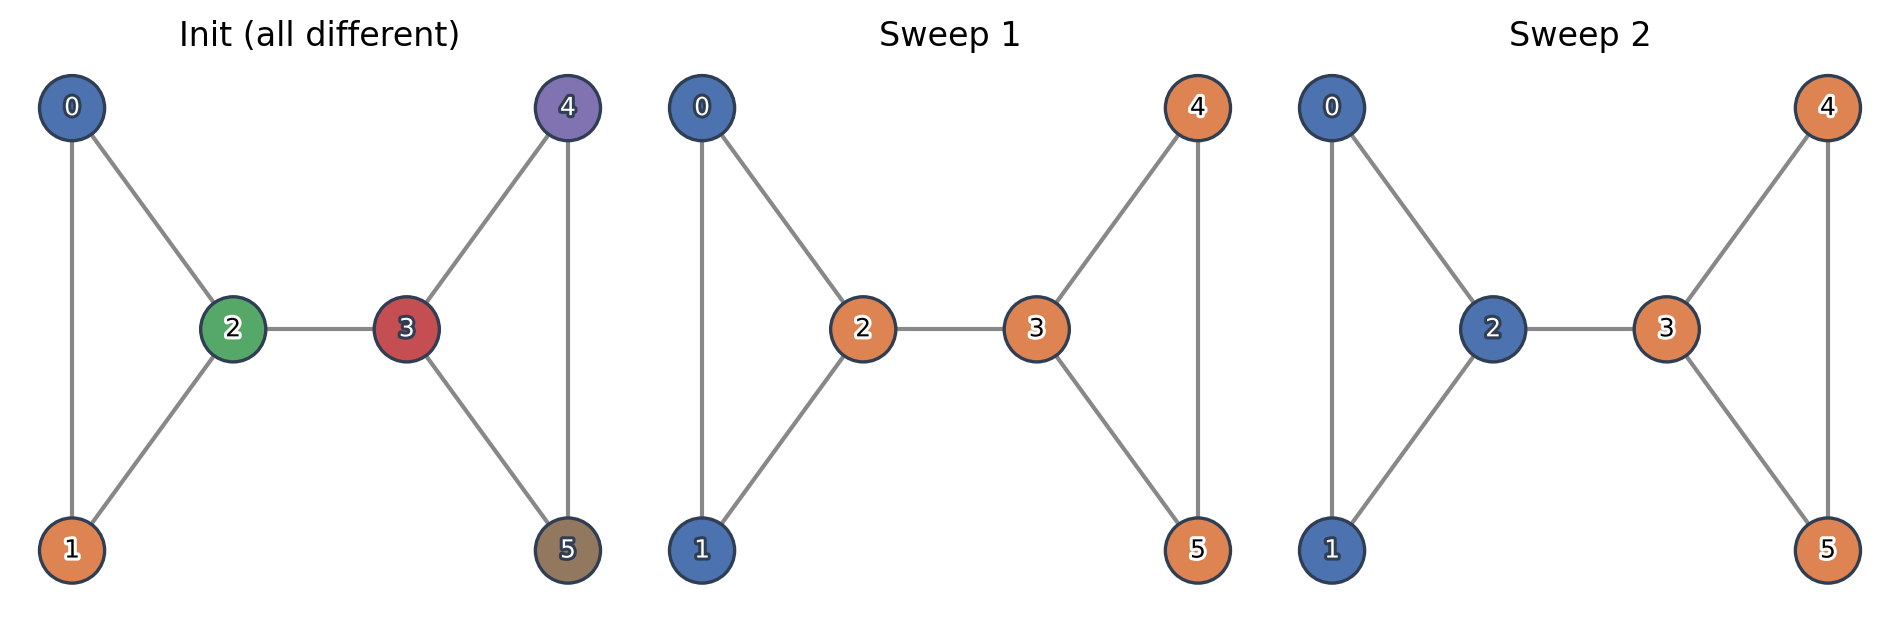

In [6]:
# Plot the graph coloured by labels after each sweep
palette = list(CATEGORY_PALETTE.values())
T = len(hist_toy)
fig, axes = plt.subplots(1, T, figsize=(3.2 * T, 3.2))
if T == 1:
    axes = [axes]
for t, ax in enumerate(axes):
    labs = hist_toy[t]
    unique = sorted(set(labs.values()))
    cmap = {u: palette[i % len(palette)] for i, u in enumerate(unique)}
    colors = [cmap[labs[n]] for n in G_toy.nodes()]
    draw_graph(G_toy, pos=pos_toy, ax=ax, node_color=colors, node_size=550, font_size=9)
    ax.set_title(f'Sweep {t}' if t > 0 else 'Init (all different)')
plt.tight_layout(); plt.show()

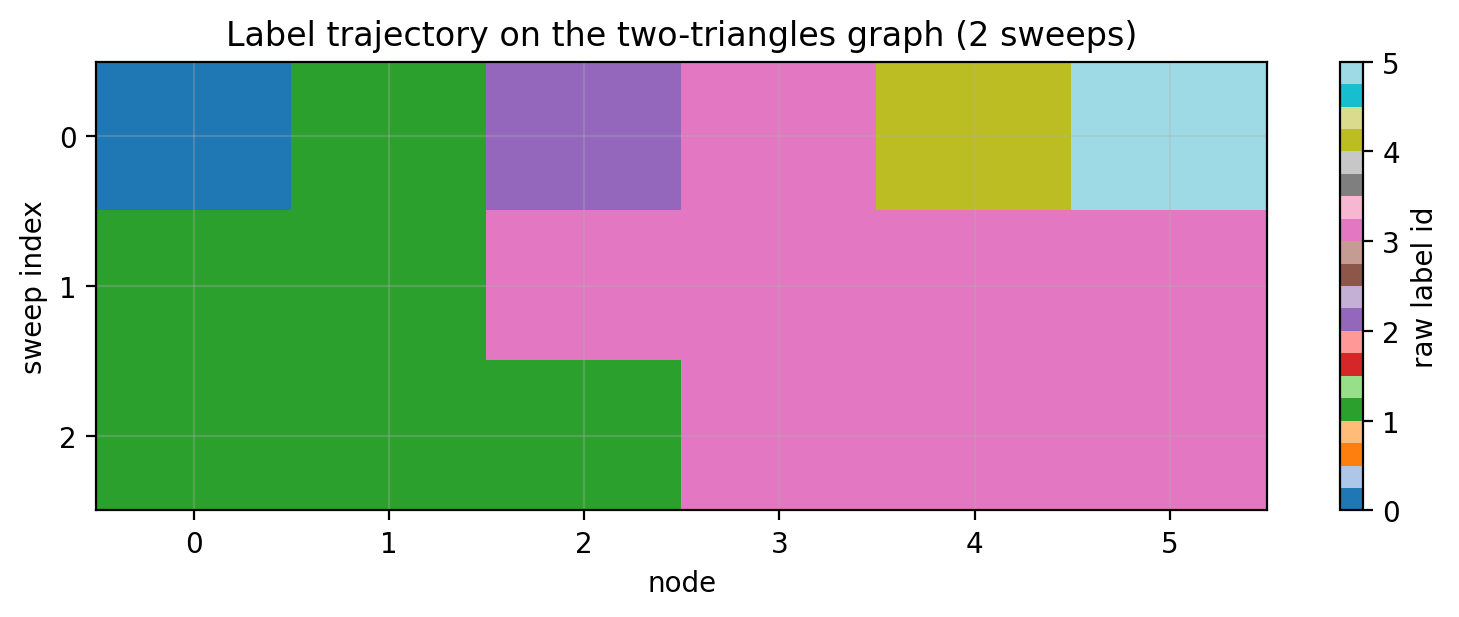

In [7]:
# Label heatmap: rows = sweeps, cols = nodes. Colours are raw label ids (categorical).
nodes_toy = list(G_toy.nodes())
mat = np.array([[hist_toy[t][v] for v in nodes_toy] for t in range(T)])

fig, ax = plt.subplots(figsize=(8, 3.2))
im = ax.imshow(mat, cmap='tab20', aspect='auto', interpolation='nearest')
ax.set_title(f'Label trajectory on the two-triangles graph ({n_sw_toy} sweeps)')
ax.set_xlabel('node'); ax.set_ylabel('sweep index')
ax.set_xticks(range(len(nodes_toy))); ax.set_xticklabels(nodes_toy)
ax.set_yticks(range(T))
plt.colorbar(im, ax=ax, label='raw label id'); plt.tight_layout(); plt.show()

**Interpretation.** After initialisation (row 0) every node has its own colour. The first sweep already fuses each triangle internally - a triangle's interior has a 2-vs-1 majority as soon as any node copies a neighbour's label. The bridge edge $(2,3)$ is visited but the majority inside each triangle is decisive, so the two communities survive. Within a couple of sweeps the stationary state is reached: every node holds the majority label of its closed neighbourhood. This is exactly the slide procedure playing out on six nodes.

**From toy to real data.**

The barbell walkthrough showed us *how* labels propagate: random sweeps, the majority rule, the
occasional random tie-break, and eventual convergence to a **stationary state**. We now run the
same algorithm on the two networks we have been following since NB 12 — Karate Club and Les
Misérables — to see whether this strictly local rule also recovers globally meaningful community
structure.

---
## 5. Label Propagation on Karate and Les Miserables

Karate | sweeps to stationary state: 2
       | communities found:          3
       | community sizes:            [19, 10, 5]


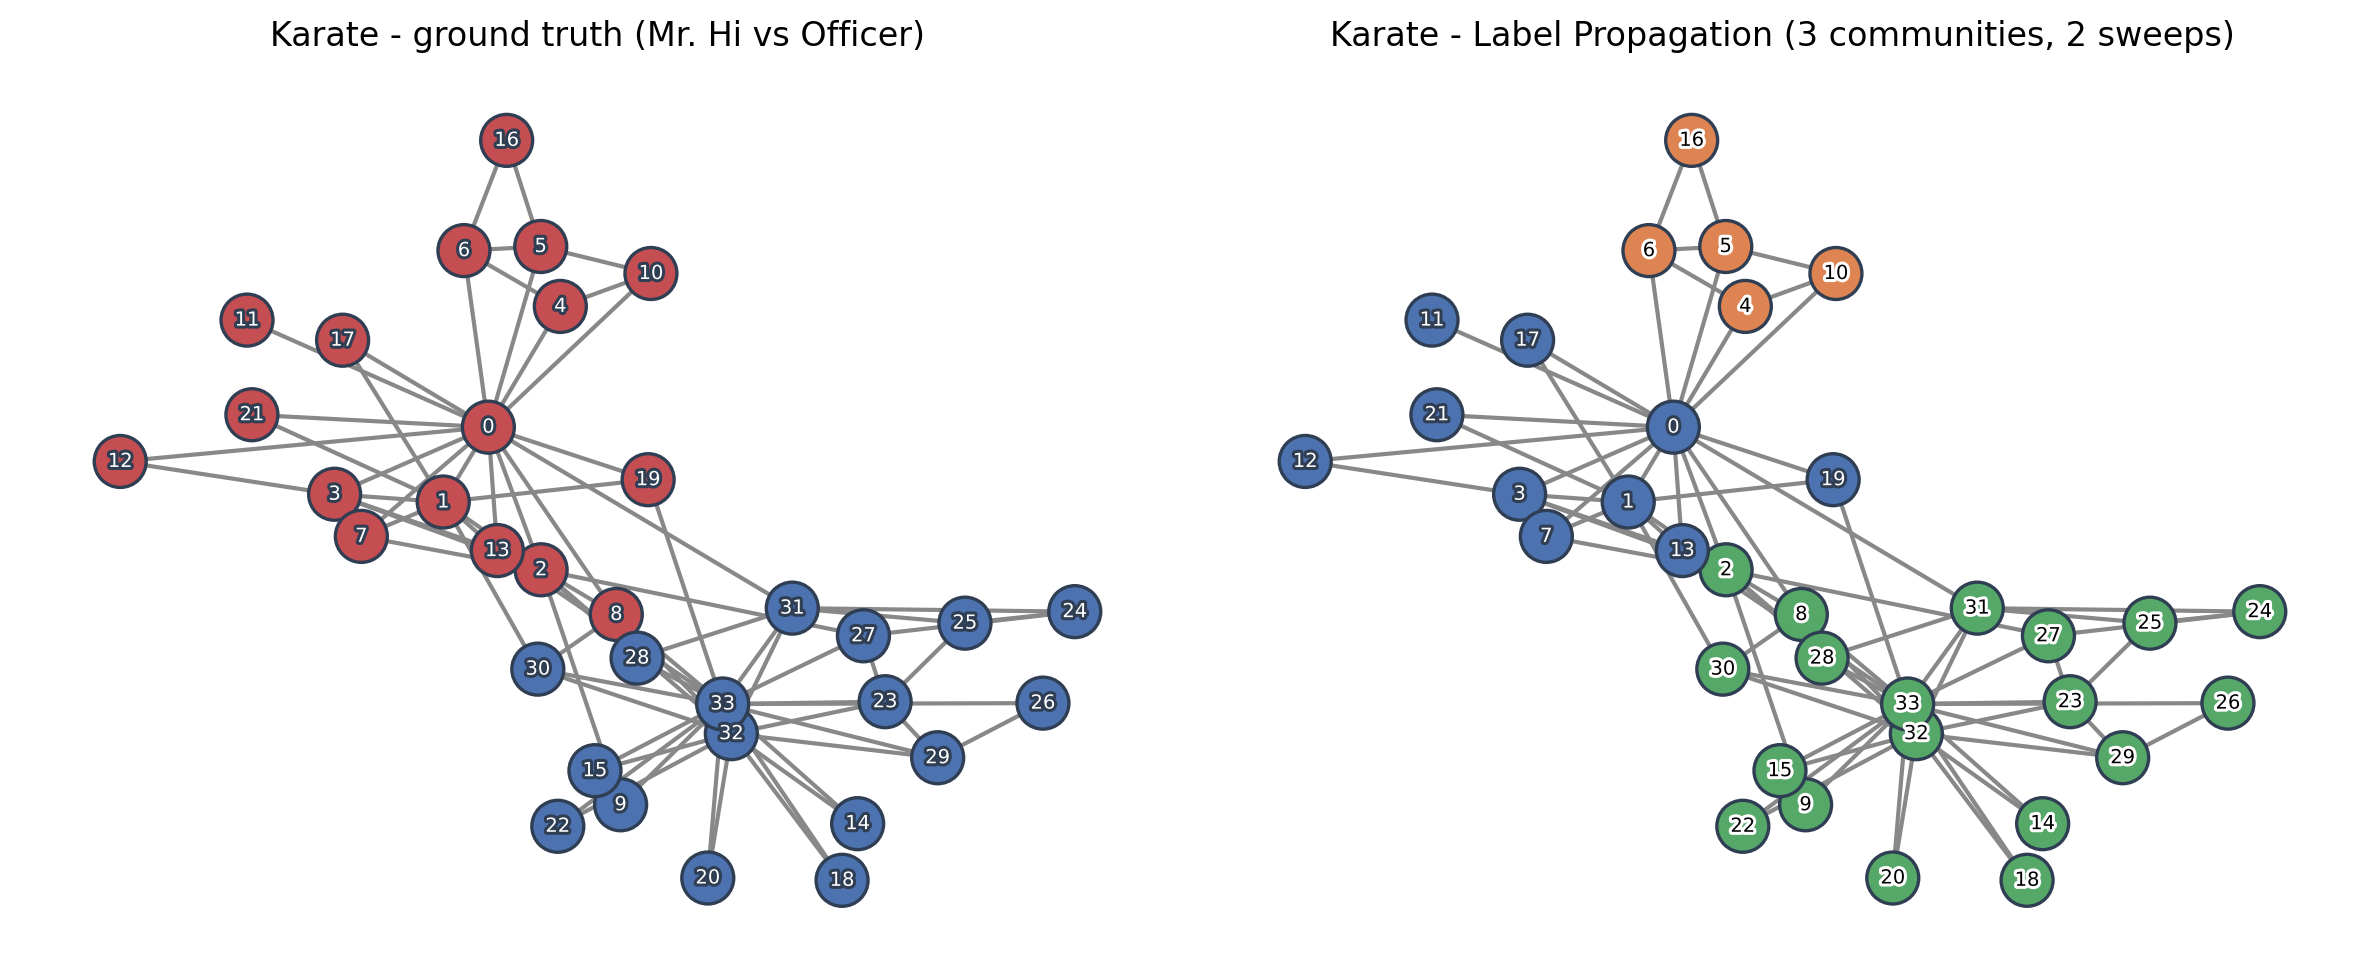

In [8]:
lab_k, n_sw_k, hist_k = label_propagation(G_karate, seed=RANDOM_SEED, record_history=True)
communities_lp_k = Counter(lab_k.values())
print(f'Karate | sweeps to stationary state: {n_sw_k}')
print(f'       | communities found:          {len(communities_lp_k)}')
print(f'       | community sizes:            {sorted(communities_lp_k.values(), reverse=True)}')

# Visualise the final partition on the canonical Karate layout
unique = sorted(set(lab_k.values()))
cmap_k = {u: palette[i % len(palette)] for i, u in enumerate(unique)}
colors_k = [cmap_k[lab_k[n]] for n in G_karate.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gt_colors = [CATEGORY_PALETTE['red'] if karate_truth[n] == 0 else CATEGORY_PALETTE['blue']
             for n in G_karate.nodes()]
draw_graph(G_karate, pos=pos_karate, ax=axes[0], node_color=gt_colors, node_size=350, font_size=7)
axes[0].set_title('Karate - ground truth (Mr. Hi vs Officer)')
draw_graph(G_karate, pos=pos_karate, ax=axes[1], node_color=colors_k, node_size=350, font_size=7)
axes[1].set_title(f'Karate - Label Propagation ({len(unique)} communities, {n_sw_k} sweeps)')
plt.tight_layout(); plt.show()

Les Mis | sweeps to stationary state: 3
        | communities found:          5
        | size distribution:          [37, 18, 8, 8, 6]


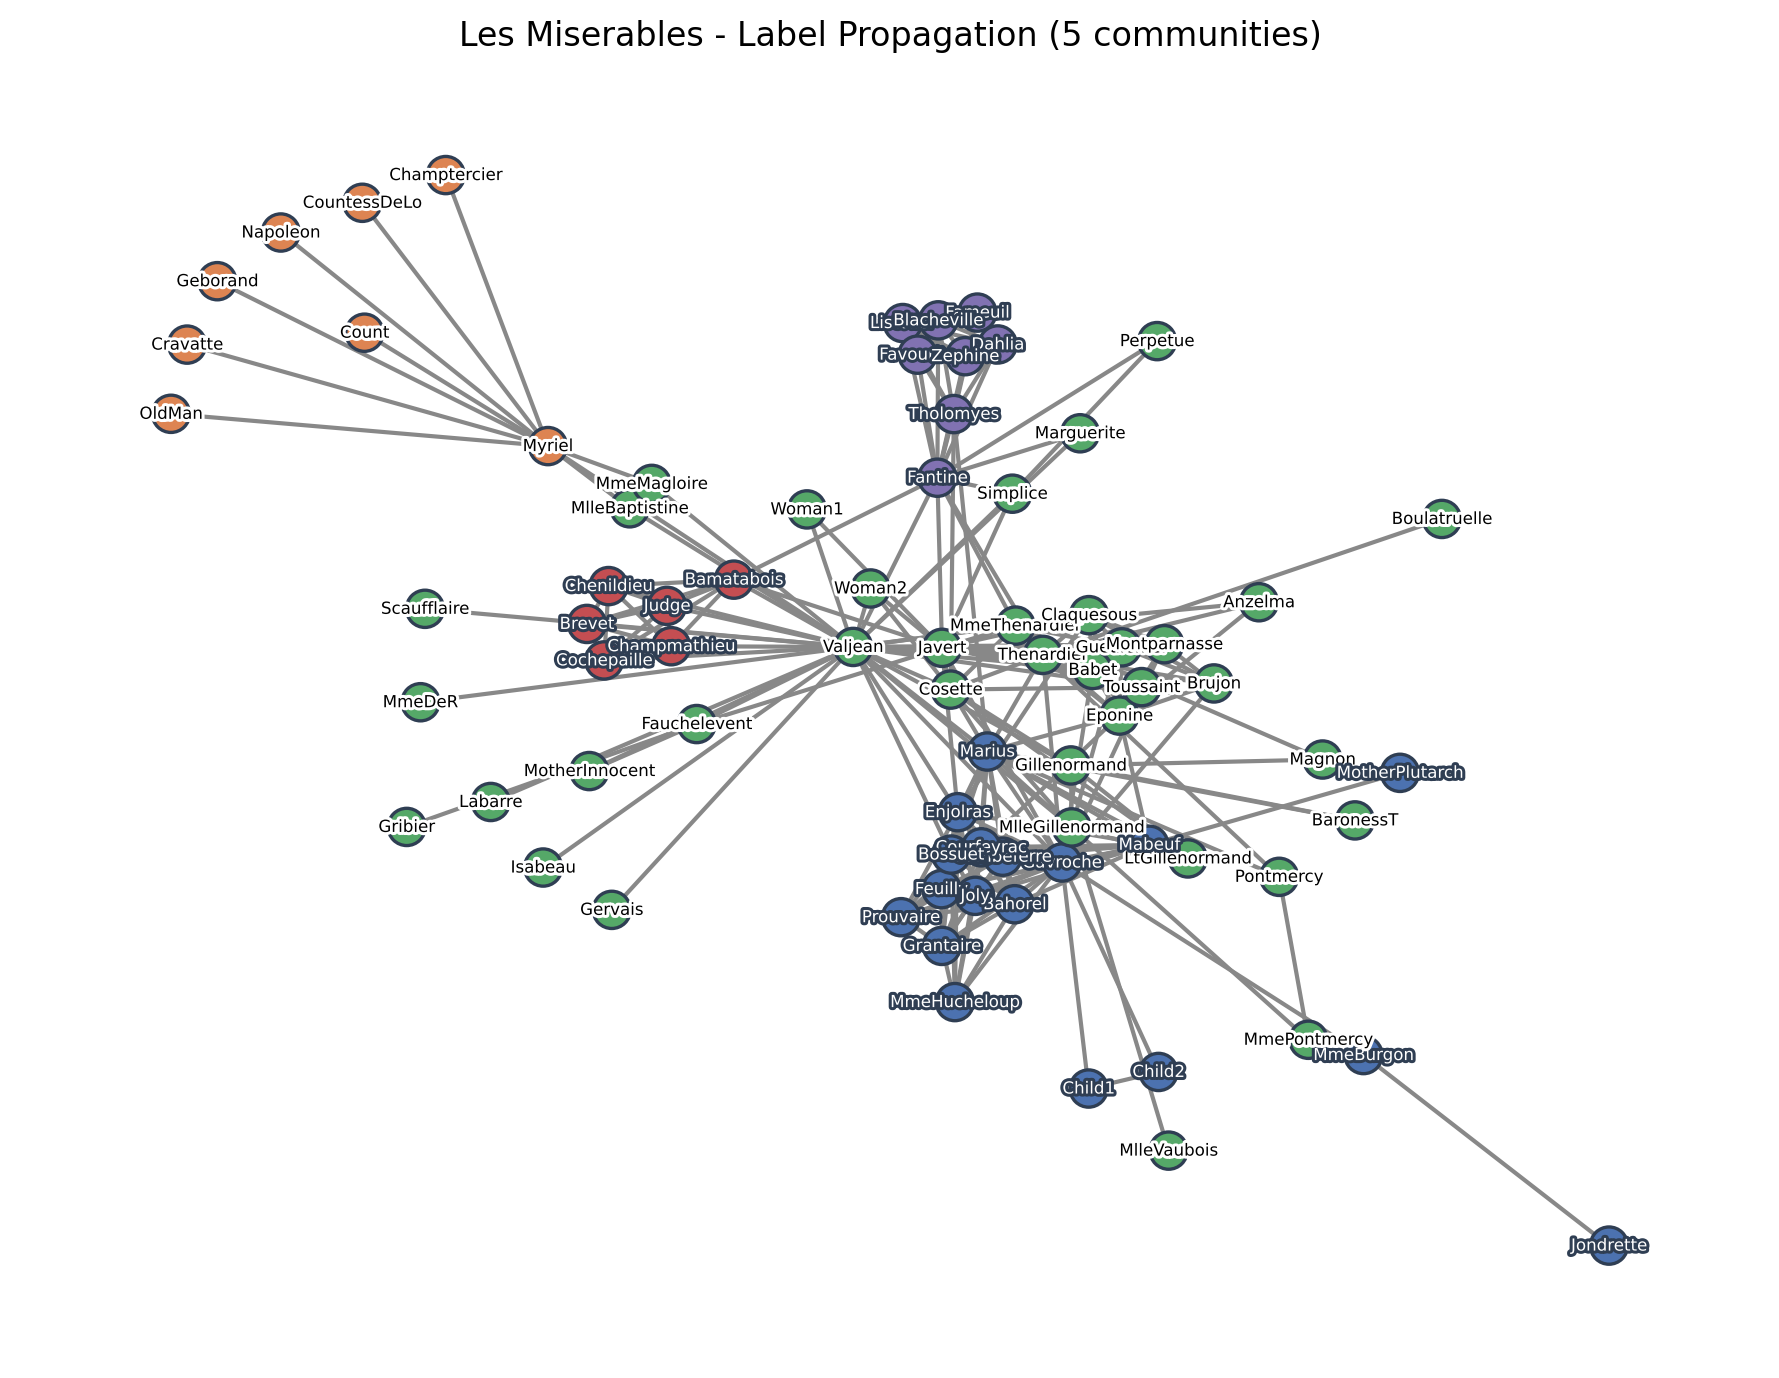

In [9]:
lab_l, n_sw_l, _ = label_propagation(G_lesmis, seed=RANDOM_SEED)
communities_lp_l = Counter(lab_l.values())
print(f'Les Mis | sweeps to stationary state: {n_sw_l}')
print(f'        | communities found:          {len(communities_lp_l)}')
print(f'        | size distribution:          {sorted(communities_lp_l.values(), reverse=True)}')

unique_l = sorted(set(lab_l.values()))
cmap_l = {u: palette[i % len(palette)] for i, u in enumerate(unique_l)}
colors_l = [cmap_l[lab_l[n]] for n in G_lesmis.nodes()]

fig, ax = plt.subplots(figsize=(9, 7))
draw_graph(G_lesmis, pos=pos_lesmis, ax=ax, node_color=colors_l, node_size=180, font_size=6)
ax.set_title(f'Les Miserables - Label Propagation ({len(unique_l)} communities)')
plt.tight_layout(); plt.show()

**Interpretation.** On Karate the final partition typically has 2-4 communities depending on the random sweep order, with the two factions largely recovered but sometimes split further. On Les Miserables LP tends to produce a *finer* partition than Louvain - character sub-plots (the Bishop, the Thenardier household, Marius's friends at the barricade) naturally split into coherent sub-groups. This is a recurring theme: LP does not *balance* community sizes; it simply waits for the dynamics to settle.

---
## 6. Properties of LP - with evidence

The slides claim four properties. We verify each one with code.

We will now **validate each of the four claims made in Section 2** with an explicit experiment:
- *Fast convergence* (6.1) — a sweep-count vs network-size scatter.
- *Each cluster is a less-stringent strong community* (6.2) — predicate check on Karate.
- *Parameter-free* (6.3) — contrast with Louvain's explicit resolution knob.
- *Instability across runs* (6.4) — distributions of $k$ and $Q$ over 50 seeds.
- And a robustification recipe — the **consensus partition** from a co-occurrence matrix (6.5).

Read each subsection as answering the question: *is the slide claim actually true?*

### 6.1 Convergence in few sweeps (almost independent of $N$)

We generate $G(N, p)$ random graphs with increasing $N$ (at fixed mean degree $\langle k \rangle \approx 8$) and record the number of sweeps LP needs to reach the stationary state.

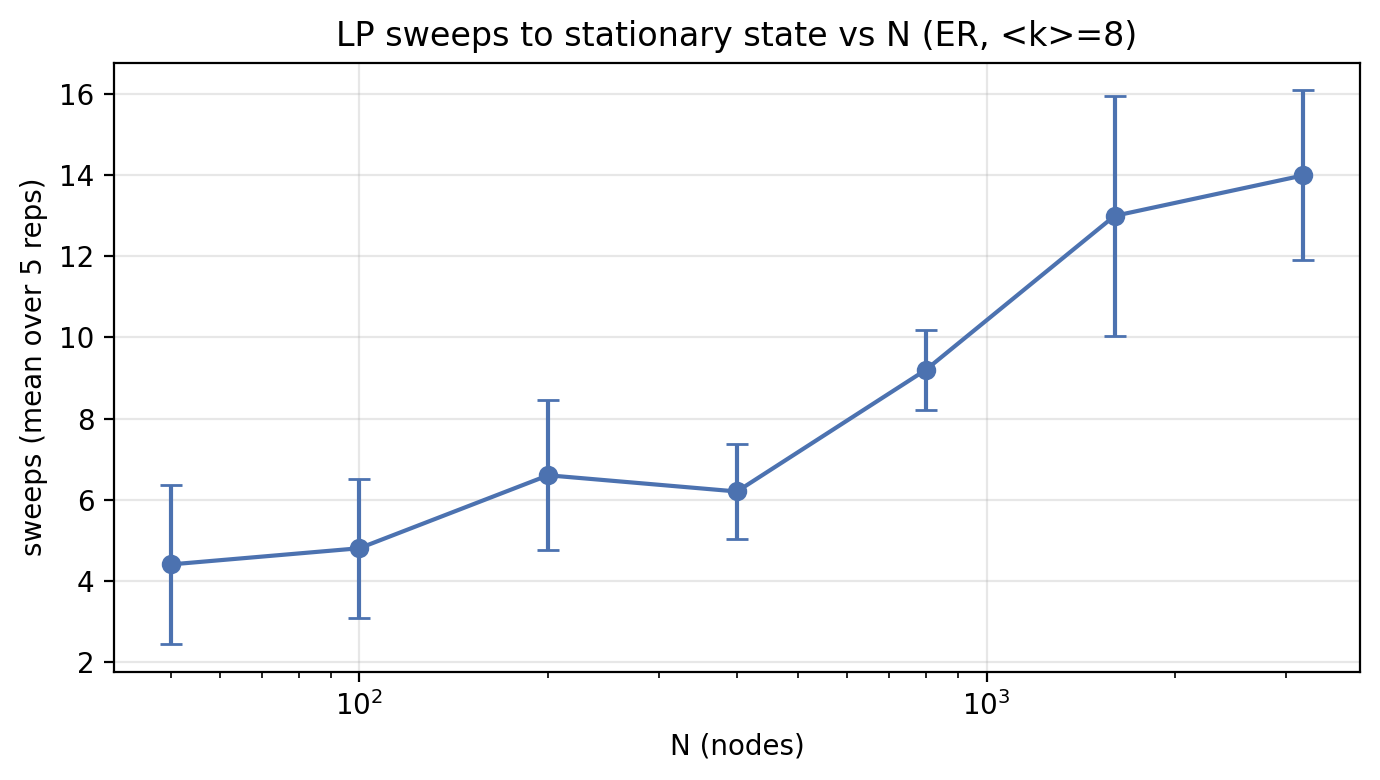

Number of sweeps grows very slowly with N - compatible with O(log N).


In [10]:
sizes = [50, 100, 200, 400, 800, 1600, 3200]
mean_deg = 8
sweeps_by_size = {N: [] for N in sizes}
for N in sizes:
    p = mean_deg / (N - 1)
    for rep in range(5):
        G_rnd = nx.erdos_renyi_graph(N, p, seed=100 + rep)
        if not nx.is_connected(G_rnd):
            G_rnd = G_rnd.subgraph(max(nx.connected_components(G_rnd), key=len)).copy()
        _, n_sw, _ = label_propagation(G_rnd, seed=rep, max_iter=200)
        sweeps_by_size[N].append(n_sw)

means = [np.mean(sweeps_by_size[N]) for N in sizes]
stds  = [np.std(sweeps_by_size[N])  for N in sizes]

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(sizes, means, yerr=stds, marker='o', color=CATEGORY_PALETTE['blue'], capsize=4)
style_axis(ax, title=f'LP sweeps to stationary state vs N (ER, <k>={mean_deg})',
           xlabel='N (nodes)', ylabel='sweeps (mean over 5 reps)', xscale='log')
plt.show()

print('Number of sweeps grows very slowly with N - compatible with O(log N).')

**Takeaway.** The number of sweeps is essentially independent of $N$ - it plateaus around 5-8 even when $N$ grows by two orders of magnitude. Combined with the $\mathcal{O}(m)$ cost per sweep, this gives LP its *near-linear* time complexity.

### 6.2 Each cluster is a less-stringent *strong community*

Recall from NB 12: a community $C$ is **strong (less-stringent)** if every node $v \in C$ has **more** neighbours in $C$ than in **any other single** community $C'$. Note this is weaker than the stringent form (majority of neighbours in $C$) but stronger than "just grouped".

This is not a coincidence: the stationary state of LP *enforces* it. If $v$'s label is the majority of its neighbourhood, no other label has strictly more neighbours of $v$.

In [11]:
def is_less_stringent_strong(G, communities):
    """Test the less-stringent strong-community predicate from NB 12 §3:
    every node has more neighbours in its own community than in any OTHER single community.
    Return a DataFrame with per-community pass/fail and the number of violating nodes.
    """
    comm_of = {v: i for i, C in enumerate(communities) for v in C}
    rows = []
    for idx, C in enumerate(communities):
        violators = []
        for v in C:
            own = sum(1 for u in G.neighbors(v) if u in C and u != v)
            # count neighbours per OTHER community
            per_other = {}
            for u in G.neighbors(v):
                if comm_of[u] != idx:
                    per_other[comm_of[u]] = per_other.get(comm_of[u], 0) + 1
            max_other = max(per_other.values()) if per_other else 0
            if own <= max_other:
                violators.append(v)
        rows.append({'community': idx, 'size': len(C),
                     'strong (less-stringent)?': len(violators) == 0,
                     'violating nodes': violators})
    return pd.DataFrame(rows)

# Apply to the Karate LP result from Section 5
lab_k_part = [set(v for v, l in lab_k.items() if l == tag) for tag in set(lab_k.values())]
display(is_less_stringent_strong(G_karate, lab_k_part))
print('Rows with "strong (less-stringent)? = True" confirm the slide claim: '
      'LP\'s clusters are strong communities in the less-stringent sense.')


,community,size,strong (less-stringent)?,violating nodes
0,0,5,True,[]
1,1,10,True,[]
2,2,19,False,[2]


Rows with "strong (less-stringent)? = True" confirm the slide claim: LP's clusters are strong communities in the less-stringent sense.


### 6.3 Parameter-free (contrast with Louvain's resolution)

Louvain implicitly depends on a resolution $\gamma$ built into its modularity objective (see NB 13). Choosing $\gamma$ changes the partition; varying $\gamma$ reveals multiple hierarchical scales.

LP has **no** such knob. It returns one partition at one natural scale - the scale where the local majority rule stabilises. This is both a strength (no tuning) and a limitation (no way to *ask* for coarser or finer communities).

### 6.4 Instability across runs: distributions of $k$ and $Q$

We run LP on Karate 50 times with different random seeds and record the number of communities and the resulting modularity.

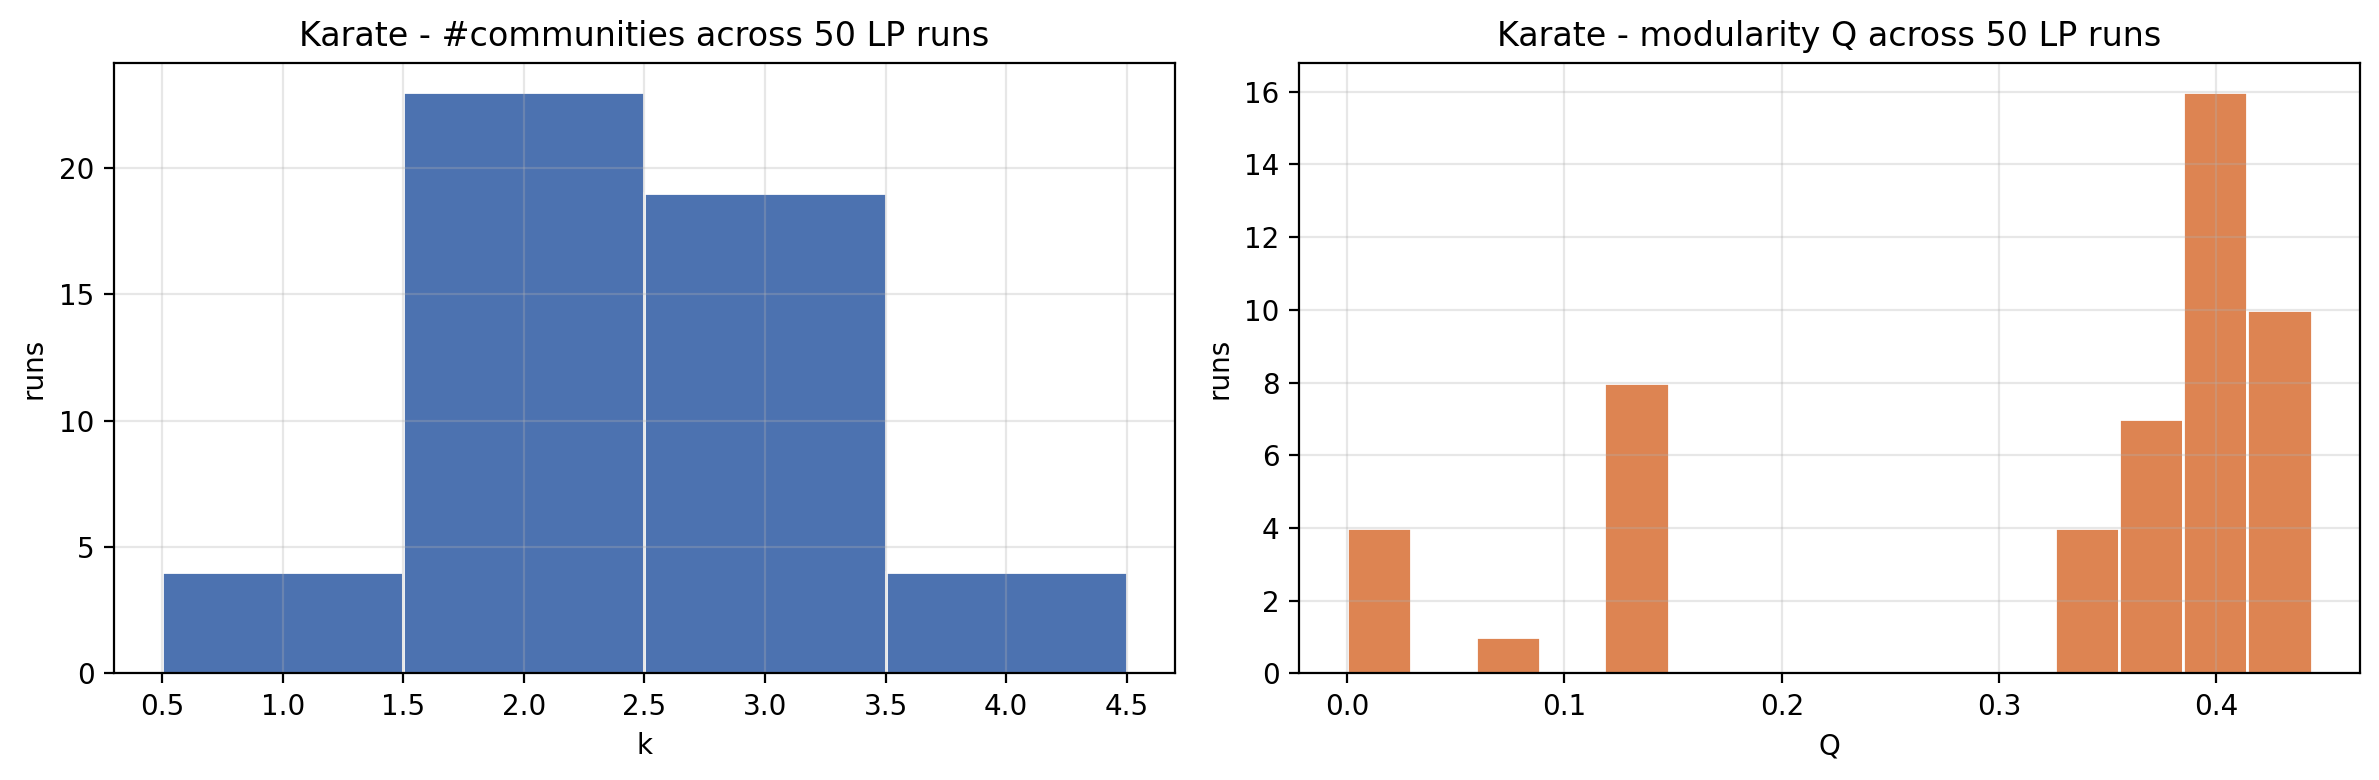

         k      Q
min   1.00  0.000
max   4.00  0.444
mean  2.46  0.320


In [12]:
R = 50
records = []
partitions_k = []
for s in range(R):
    lab, _, _ = label_propagation(G_karate, seed=s)
    comms = labels_to_communities(G_karate, dict_to_labels(G_karate, lab))
    partitions_k.append(comms)
    Q = nx.community.modularity(G_karate, comms)
    records.append({'seed': s, 'k': len(comms), 'Q': Q})
df_lp_k = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_lp_k['k'], bins=range(df_lp_k['k'].min(), df_lp_k['k'].max()+2),
             color=CATEGORY_PALETTE['blue'], edgecolor='white', align='left')
style_axis(axes[0], title=f'Karate - #communities across {R} LP runs', xlabel='k', ylabel='runs')
axes[1].hist(df_lp_k['Q'], bins=15, color=CATEGORY_PALETTE['orange'], edgecolor='white')
style_axis(axes[1], title=f'Karate - modularity Q across {R} LP runs', xlabel='Q', ylabel='runs')
plt.show()

print(df_lp_k.agg({'k': ['min','max','mean'], 'Q': ['min','max','mean']}).round(3))

**Interpretation.** The same algorithm on the same graph delivers a *distribution* of outputs. Both $k$ and $Q$ spread over a non-trivial range. The randomness comes from two sources: (i) the random node visit order in each sweep; (ii) random tie-breaking when several labels share the majority. This is an intrinsic feature, not a bug - it is telling us that at this scale there are several *equally valid* stationary states.

### 6.5 Consensus partition from the co-occurrence matrix

A standard robustification: run LP $R$ times and form the **co-occurrence matrix**
$$M_{ij} \;=\; \frac{1}{R}\sum_{r=1}^R \mathbf{1}\big[\text{nodes } i,j \text{ co-clustered in run } r\big].$$
Entries near 1 indicate stable *core* pairs; intermediate entries indicate *boundary* nodes whose assignment fluctuates. A **consensus partition** is obtained by running an agglomerative clustering on the distance $D_{ij} = 1 - M_{ij}$.

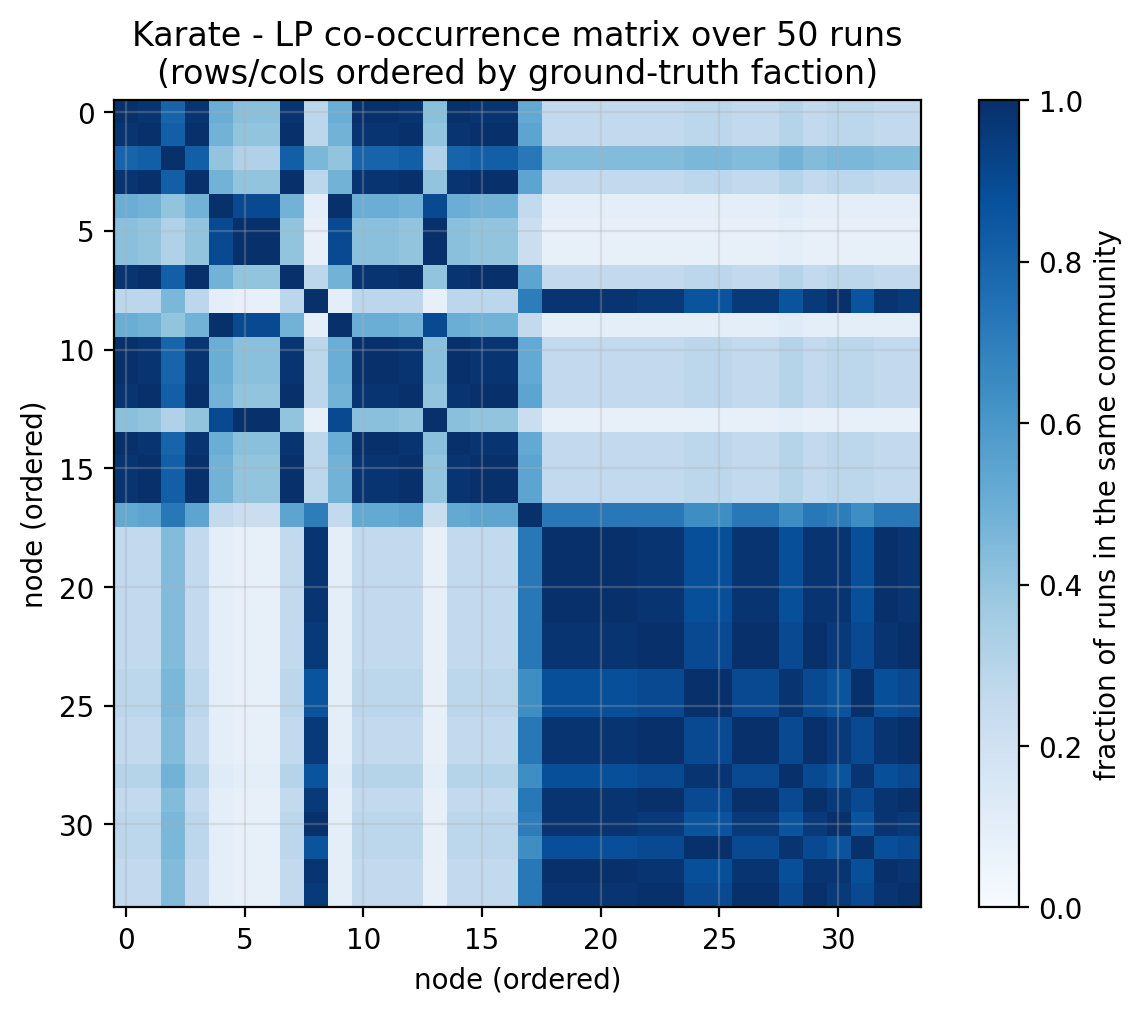

In [13]:
nodes = list(G_karate.nodes())
idx = {n: i for i, n in enumerate(nodes)}
N = len(nodes)
co = np.zeros((N, N))
for comms in partitions_k:
    for C in comms:
        C = list(C)
        for u in C:
            for v in C:
                co[idx[u], idx[v]] += 1
co /= len(partitions_k)

# Reorder by ground truth to reveal block structure
order = sorted(nodes, key=lambda n: karate_truth[n])
perm = [idx[n] for n in order]
co_ord = co[np.ix_(perm, perm)]

fig, ax = plt.subplots(figsize=(6.5, 5.2))
im = ax.imshow(co_ord, cmap='Blues', vmin=0, vmax=1)
ax.set_title(f'Karate - LP co-occurrence matrix over {len(partitions_k)} runs\n(rows/cols ordered by ground-truth faction)')
ax.set_xlabel('node (ordered)'); ax.set_ylabel('node (ordered)')
plt.colorbar(im, ax=ax, label='fraction of runs in the same community')
plt.tight_layout(); plt.show()

In [14]:
# Extract a consensus partition by agglomerative clustering on D = 1 - M
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

D = 1.0 - co
np.fill_diagonal(D, 0.0)
# Symmetrise (numerical safety)
D = (D + D.T) / 2.0
condensed = squareform(D, checks=False)
Z = linkage(condensed, method='average')

# Cut at 2 clusters to match the known ground-truth granularity
cluster_ids = fcluster(Z, t=2, criterion='maxclust')
consensus_labels = {nodes[i]: int(cluster_ids[i]) for i in range(N)}

pred_consensus = dict_to_labels(G_karate, consensus_labels)
truth_k        = dict_to_labels(G_karate, karate_truth)
pred_single    = dict_to_labels(G_karate, lab_k)

print('Single LP run     vs ground truth:', 
      f"NMI={normalized_mutual_info_score(truth_k, pred_single):.3f}",
      f"ARI={adjusted_rand_score(truth_k, pred_single):.3f}")
print('Consensus LP (50) vs ground truth:', 
      f"NMI={normalized_mutual_info_score(truth_k, pred_consensus):.3f}",
      f"ARI={adjusted_rand_score(truth_k, pred_consensus):.3f}")

Single LP run     vs ground truth: NMI=0.608 ARI=0.591
Consensus LP (50) vs ground truth: NMI=0.837 ARI=0.882


**Takeaway.** The consensus partition is typically *at least as good* as an individual run and usually better - it averages out the randomness and restores a more robust bipartition. This is the standard way to report LP results in papers: run many times, cluster on co-occurrence, report the consensus.

---
## 7. Semi-supervised Label Propagation with seeds

Many real problems sit between supervised and unsupervised: some labels are known (verified political affiliations, a few annotated proteins, hand-labelled users) and we want to *propagate* them to the rest of the graph.

LP needs no algorithmic change - we simply initialise the known nodes with their labels and (optionally) **pin** them so they never change. Everything else starts with its own unique label and propagates.

In [15]:
# Seed Karate with the two faction leaders: node 0 (Mr. Hi) and node 33 (Officer)
seeds = {0: 0, 33: 1}
pinned = set(seeds)

lab_seeded, n_sw, _ = label_propagation(G_karate, seed=RANDOM_SEED,
                                         initial_labels=seeds, pinned=pinned)
pred = dict_to_labels(G_karate, lab_seeded)
print(f'Seeded LP | sweeps: {n_sw}   k: {len(set(pred))}')
print(f'          | NMI vs ground truth: {normalized_mutual_info_score(truth_k, pred):.3f}')
print(f'          | ARI vs ground truth: {adjusted_rand_score(truth_k, pred):.3f}')

Seeded LP | sweeps: 4   k: 2
          | NMI vs ground truth: 0.411
          | ARI vs ground truth: 0.329


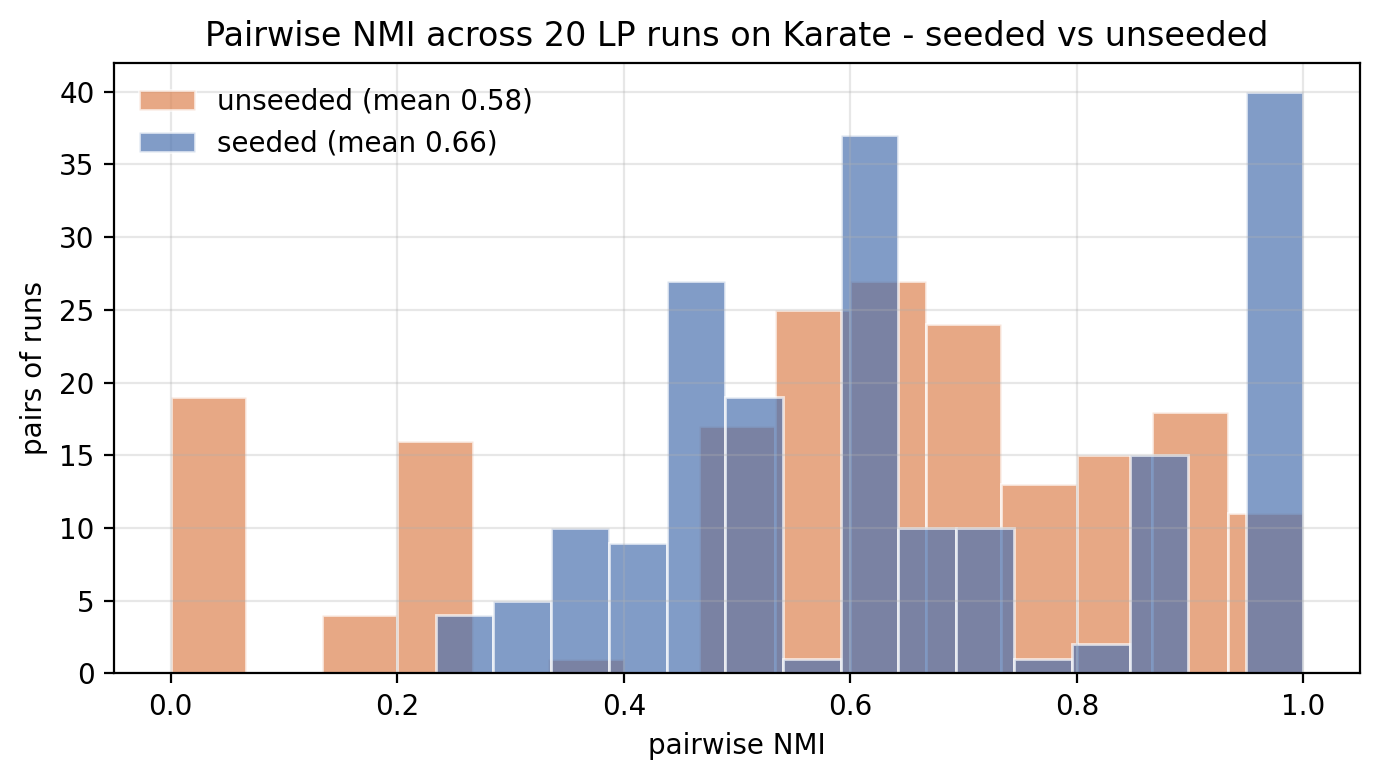

In [16]:
# Compare the stability of unseeded vs seeded LP across 20 runs
def lp_labels(G, seed, seeds=None):
    init = seeds if seeds else None
    pin  = set(seeds) if seeds else None
    lab, _, _ = label_propagation(G, seed=seed, initial_labels=init, pinned=pin)
    return dict_to_labels(G, lab)

runs_un, runs_sd = [], []
for s in range(20):
    runs_un.append(lp_labels(G_karate, s))
    runs_sd.append(lp_labels(G_karate, s, seeds=seeds))

def pairwise_nmi(runs):
    R = len(runs)
    vals = []
    for i in range(R):
        for j in range(i+1, R):
            vals.append(normalized_mutual_info_score(runs[i], runs[j]))
    return np.array(vals)

nmi_un = pairwise_nmi(runs_un)
nmi_sd = pairwise_nmi(runs_sd)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(nmi_un, bins=15, alpha=0.7, color=CATEGORY_PALETTE['orange'],
        edgecolor='white', label=f'unseeded (mean {nmi_un.mean():.2f})')
ax.hist(nmi_sd, bins=15, alpha=0.7, color=CATEGORY_PALETTE['blue'],
        edgecolor='white', label=f'seeded (mean {nmi_sd.mean():.2f})')
style_axis(ax, title='Pairwise NMI across 20 LP runs on Karate - seeded vs unseeded',
           xlabel='pairwise NMI', ylabel='pairs of runs', legend=True)
plt.show()

**Takeaway.** Just **two** seeds - the two faction leaders - concentrate the pairwise NMI distribution near 1. The semi-supervised variant is therefore not just *more accurate* against ground truth; it is also *more stable across runs*. Seeds anchor the label dynamics in the basins we care about.

**A gap we have been filling with hand-waving.**

Throughout NB 12, NB 13 and the previous sections of this notebook we have often said "this
partition is similar to the ground truth" or "these two Louvain runs differ." It is time to put
numbers on the word *similar*. Section 8 introduces three formal partition-comparison tools —
**NMI**, **ARI**, and the **Jaccard index for pairs** — and applies them consistently to every
algorithm we have met.

---

---
## 8. Comparing partitions - NMI, ARI, Jaccard

Given two partitions $\mathcal{A}$ and $\mathcal{B}$ of the same node set we need a *scalar* that quantifies their similarity. Modularity is *not* such a scalar - it scores one partition against the null model, not two partitions against each other. We introduce three complementary measures.

### 8.1 Confusion matrix

The **confusion matrix** $C$ has $C_{ij} = |A_i \cap B_j|$ = number of nodes simultaneously in community $A_i$ and community $B_j$.

### 8.2 A worked example on 6 nodes

Let
- $\mathcal{A} = \{\{1,2,3\},\{4,5,6\}\}$  (two classes, $k_A = 2$)
- $\mathcal{B} = \{\{1,2\},\{3,4,5\},\{6\}\}$ (three classes, $k_B = 3$)

The confusion matrix, computed by hand, is

|            | $B_1{=}\{1,2\}$ | $B_2{=}\{3,4,5\}$ | $B_3{=}\{6\}$ | row sum |
|-----------|:---:|:---:|:---:|:---:|
| $A_1{=}\{1,2,3\}$ | 2 | 1 | 0 | 3 |
| $A_2{=}\{4,5,6\}$ | 0 | 2 | 1 | 3 |
| **col sum**       | 2 | 3 | 1 | 6 |

We now verify it in code.

In [17]:
A = [{1,2,3}, {4,5,6}]
B = [{1,2},   {3,4,5}, {6}]

def confusion_matrix(A, B):
    kA, kB = len(A), len(B)
    C = np.zeros((kA, kB), dtype=int)
    for i, Ai in enumerate(A):
        for j, Bj in enumerate(B):
            C[i, j] = len(Ai & Bj)
    return C

CM = confusion_matrix(A, B)
print('Confusion matrix C (rows = A, cols = B):')
print(CM)

Confusion matrix C (rows = A, cols = B):
[[2 1 0]
 [0 2 1]]


### 8.3 NMI step-by-step

Set $p_{ij} = C_{ij}/N$, $p_i^A = \sum_j p_{ij}$, $p_j^B = \sum_i p_{ij}$. With $N=6$:

- Joint distribution $p_{ij}$: $\{2/6, 1/6, 0, 0, 2/6, 1/6\}$.
- Marginals: $p^A = (3/6, 3/6)$, $p^B = (2/6, 3/6, 1/6)$.

Entropies (natural log for arithmetic; the ratio is invariant):
$$H(A) = -\sum_i p_i^A \log p_i^A,\quad H(B) = -\sum_j p_j^B \log p_j^B.$$

Mutual information:
$$I(A,B) = \sum_{ij} p_{ij} \log \frac{p_{ij}}{p_i^A p_j^B}.$$

Normalised:
$$\mathrm{NMI}(A,B) = \frac{2 I(A,B)}{H(A) + H(B)} \;\in\; [0,1].$$

We compute them numerically.

In [18]:
def entropy(p):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return -float(np.sum(p * np.log(p)))

N = CM.sum()
P = CM / N
pA = P.sum(axis=1)
pB = P.sum(axis=0)
HA = entropy(pA); HB = entropy(pB)

I = 0.0
for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        if P[i, j] > 0:
            I += P[i, j] * np.log(P[i, j] / (pA[i] * pB[j]))

nmi_manual = 2 * I / (HA + HB)

# Cross-check with sklearn using node->label vectors
nodes_67 = [1,2,3,4,5,6]
labA = np.array([0 if n in A[0] else 1 for n in nodes_67])
labB = np.array([0 if n in B[0] else (1 if n in B[1] else 2) for n in nodes_67])
nmi_sklearn = normalized_mutual_info_score(labA, labB)

print(f'H(A) = {HA:.4f}')
print(f'H(B) = {HB:.4f}')
print(f'I(A,B) = {I:.4f}')
print(f'NMI (manual)   = {nmi_manual:.4f}')
print(f'NMI (sklearn)  = {nmi_sklearn:.4f}')

H(A) = 0.6931
H(B) = 1.0114
I(A,B) = 0.3749
NMI (manual)   = 0.4399
NMI (sklearn)  = 0.4399


### 8.4 ARI step-by-step

The **Adjusted Rand Index** counts *pairs of nodes* that are classified consistently - same-same or different-different - and corrects for chance. With $n_{ij} = C_{ij}$, $a_i = \sum_j n_{ij}$, $b_j = \sum_i n_{ij}$:

$$\mathrm{ARI} = \frac{\sum_{ij}\binom{n_{ij}}{2} - \big[\sum_i \binom{a_i}{2}\sum_j \binom{b_j}{2}\big]/\binom{N}{2}}{\tfrac{1}{2}\big[\sum_i \binom{a_i}{2}+\sum_j \binom{b_j}{2}\big] - \big[\sum_i \binom{a_i}{2}\sum_j \binom{b_j}{2}\big]/\binom{N}{2}}.$$

ARI is 1 for identical partitions, 0 for what you would get by chance, and can be **negative** for worse-than-random agreement.

In [19]:
from math import comb

n_ij = CM
a = n_ij.sum(axis=1); b = n_ij.sum(axis=0)
sum_n = sum(comb(int(x), 2) for x in n_ij.flatten())
sum_a = sum(comb(int(x), 2) for x in a)
sum_b = sum(comb(int(x), 2) for x in b)
expected = sum_a * sum_b / comb(int(N), 2)
max_idx  = 0.5 * (sum_a + sum_b)
ari_manual = (sum_n - expected) / (max_idx - expected)
ari_sklearn = adjusted_rand_score(labA, labB)
print(f'ARI (manual)  = {ari_manual:.4f}')
print(f'ARI (sklearn) = {ari_sklearn:.4f}')

ARI (manual)  = 0.1176
ARI (sklearn) = 0.1176


### 8.5 Jaccard index for pair agreement

A third, conceptually simpler measure looks at every pair of nodes and asks:
- $a$ = pairs that are *together in both* $\mathcal{A}$ and $\mathcal{B}$,
- $b$ = pairs together in $\mathcal{A}$ only,
- $c$ = pairs together in $\mathcal{B}$ only.

Then $\mathrm{Jaccard} = a / (a + b + c)$.

In [20]:
def pair_jaccard(labA, labB):
    n = len(labA)
    a = b = c = 0
    for i in range(n):
        for j in range(i+1, n):
            sameA = labA[i] == labA[j]
            sameB = labB[i] == labB[j]
            if sameA and sameB: a += 1
            elif sameA:         b += 1
            elif sameB:         c += 1
    return a / (a + b + c) if (a + b + c) else 1.0

print(f'Jaccard pair index = {pair_jaccard(labA, labB):.4f}')

Jaccard pair index = 0.2500


### 8.6 Boundary checks on synthetic partitions

Let us verify the expected behaviour on three canonical cases.

In [21]:
rng = np.random.default_rng(RANDOM_SEED)
N = 200
x = rng.integers(0, 4, N)

identical = x
random_   = rng.integers(0, 4, N)
opposite  = (x + 1) % 4   # systematic relabelling

rows = []
for name, y in [('Identical', identical), ('Independent random', random_), ('Systematic relabel', opposite)]:
    rows.append({'case': name,
                 'NMI': round(normalized_mutual_info_score(x, y), 3),
                 'ARI': round(adjusted_rand_score(x, y), 3),
                 'Jaccard': round(pair_jaccard(x, y), 3)})
display(pd.DataFrame(rows))

,case,NMI,ARI,Jaccard
0,Identical,1.000,1.000,1.000
1,Independent random,0.025,0.008,0.145
2,Systematic relabel,1.000,1.000,1.000


**Interpretation.**
- *Identical*: all three measures saturate at 1.
- *Random*: NMI and ARI drop near 0 (ARI can even go slightly negative on small samples).
- *Systematic relabel*: NMI and ARI are 1 because they are *invariant to label permutations* - they care about the partition, not the label names. This is why they are the right tool for community detection (where labels are arbitrary).

### 8.7 Choosing a metric — quick guide

| Metric | Sees | Strength | Watch out for |
|---|---|---|---|
| **NMI** | label-set agreement (entropy of co-occurrence) | invariant to label permutation; well-defined when $k$ differs across partitions | biased upward when one partition has many tiny clusters — prefer the *adjusted* AMI for that case |
| **ARI** | agreement on **pairs** of nodes (same / different cluster) | corrected for chance, so random partitions score $\approx 0$ | drops fast when cluster sizes are very imbalanced; can go negative |
| **Jaccard (pair-agreement)** | only the pairs put **together** | symmetric, intuitive, easy to teach | ignores the pairs put apart, so "everything in one cluster" can score artificially high |

Rule of thumb for this course:
- **Compare against ground truth** $\to$ ARI (pair-counting, chance-corrected).
- **Compare two algorithm outputs with different $k$** $\to$ NMI.
- **One-number sanity check** $\to$ Jaccard, then look at NMI/ARI for confirmation.

### 8.7 Applying the tools to earlier notebooks

We can now put numbers on observations we made in NB 12 and NB 13.

- *NB 12*: Kernighan-Lin bisection on Karate vs ground truth.
- *NB 13*: Louvain vs Louvain-with-different-seed on Les Mis - the **degeneracy** diagnostic.

In [22]:
# NB 12 revisited
kl_A, kl_B = nx.community.kernighan_lin_bisection(G_karate, seed=RANDOM_SEED)
kl_labels = partition_to_labels(G_karate, [kl_A, kl_B])
print('Kernighan-Lin vs ground truth (Karate):',
      f"NMI={normalized_mutual_info_score(truth_k, kl_labels):.3f}",
      f"ARI={adjusted_rand_score(truth_k, kl_labels):.3f}")

# NB 13 revisited: Louvain degeneracy
louvain_seed_a = nx.community.louvain_communities(G_lesmis, seed=1)
louvain_seed_b = nx.community.louvain_communities(G_lesmis, seed=2)
la = partition_to_labels(G_lesmis, louvain_seed_a)
lb = partition_to_labels(G_lesmis, louvain_seed_b)
print('Louvain seed 1 vs Louvain seed 2 (Les Mis):',
      f"NMI={normalized_mutual_info_score(la, lb):.3f}",
      f"ARI={adjusted_rand_score(la, lb):.3f}")

Kernighan-Lin vs ground truth (Karate): NMI=0.677 ARI=0.772
Louvain seed 1 vs Louvain seed 2 (Les Mis): NMI=0.953 ARI=0.930


**Takeaway.** KL on Karate achieves a high NMI/ARI, confirming its balanced cut coincides with the social faction. Louvain with two seeds yields NMI well below 1 - *the same algorithm on the same graph disagrees with itself*. This is the degeneracy phenomenon we will revisit in Section 10.

---
## 9. Benchmark - Karate Club (with ground truth)

We run **all five** algorithms from NB 12-14 on the same graph, measure $k$, $Q$, NMI/ARI vs ground truth, and runtime (min-of-5 repetitions for stability).

In [23]:
def kl_partition(G, seed):
    A, B = nx.community.kernighan_lin_bisection(G, seed=seed)
    return [set(A), set(B)]

def gn_best_Q(G, max_levels=20):
    best, best_Q = None, -np.inf
    for i, comms in enumerate(nx.community.girvan_newman(G)):
        comms = [set(c) for c in comms]
        Q = nx.community.modularity(G, comms)
        if Q > best_Q:
            best_Q = Q; best = comms
        if i + 1 >= max_levels:
            break
    return best

def lp_networkx_partition(G, seed):
    return list(nx.community.asyn_lpa_communities(G, seed=seed))

def time_min(fn, repeat=5):
    best_t, result = float('inf'), None
    for _ in range(repeat):
        t0 = time.perf_counter()
        result = fn()
        dt = time.perf_counter() - t0
        if dt < best_t:
            best_t = dt
    return result, best_t

truth_k = dict_to_labels(G_karate, karate_truth)

algo_factories = {
    'Kernighan-Lin':          lambda: kl_partition(G_karate, RANDOM_SEED),
    'Girvan-Newman (best Q)': lambda: gn_best_Q(G_karate, max_levels=20),
    'Greedy modularity':      lambda: list(nx.community.greedy_modularity_communities(G_karate)),
    'Louvain':                lambda: nx.community.louvain_communities(G_karate, seed=RANDOM_SEED),
    'Label Propagation':      lambda: lp_networkx_partition(G_karate, seed=RANDOM_SEED),
}

bench = {}
rows = []
for name, fn in algo_factories.items():
    comms, dt = time_min(fn, repeat=5)
    bench[name] = comms
    pred = partition_to_labels(G_karate, comms)
    rows.append({
        'algorithm': name,
        'k': len(comms),
        'Q': round(nx.community.modularity(G_karate, comms), 3),
        'NMI vs truth': round(normalized_mutual_info_score(truth_k, pred), 3),
        'ARI vs truth': round(adjusted_rand_score(truth_k, pred), 3),
        'runtime (ms, min of 5)': round(1000 * dt, 2),
    })
df_bench_karate = pd.DataFrame(rows)
display(df_bench_karate)

,algorithm,k,Q,NMI vs truth,ARI vs truth,"runtime (ms, min of 5)"
0,Kernighan-Lin,2,0.400,0.677,0.772,0.19
1,Girvan-Newman (best Q),5,0.385,0.485,0.392,22.19
2,Greedy modularity,3,0.411,0.565,0.568,1.17
3,Louvain,4,0.427,0.594,0.491,0.50
4,Label Propagation,4,0.437,0.506,0.459,0.16


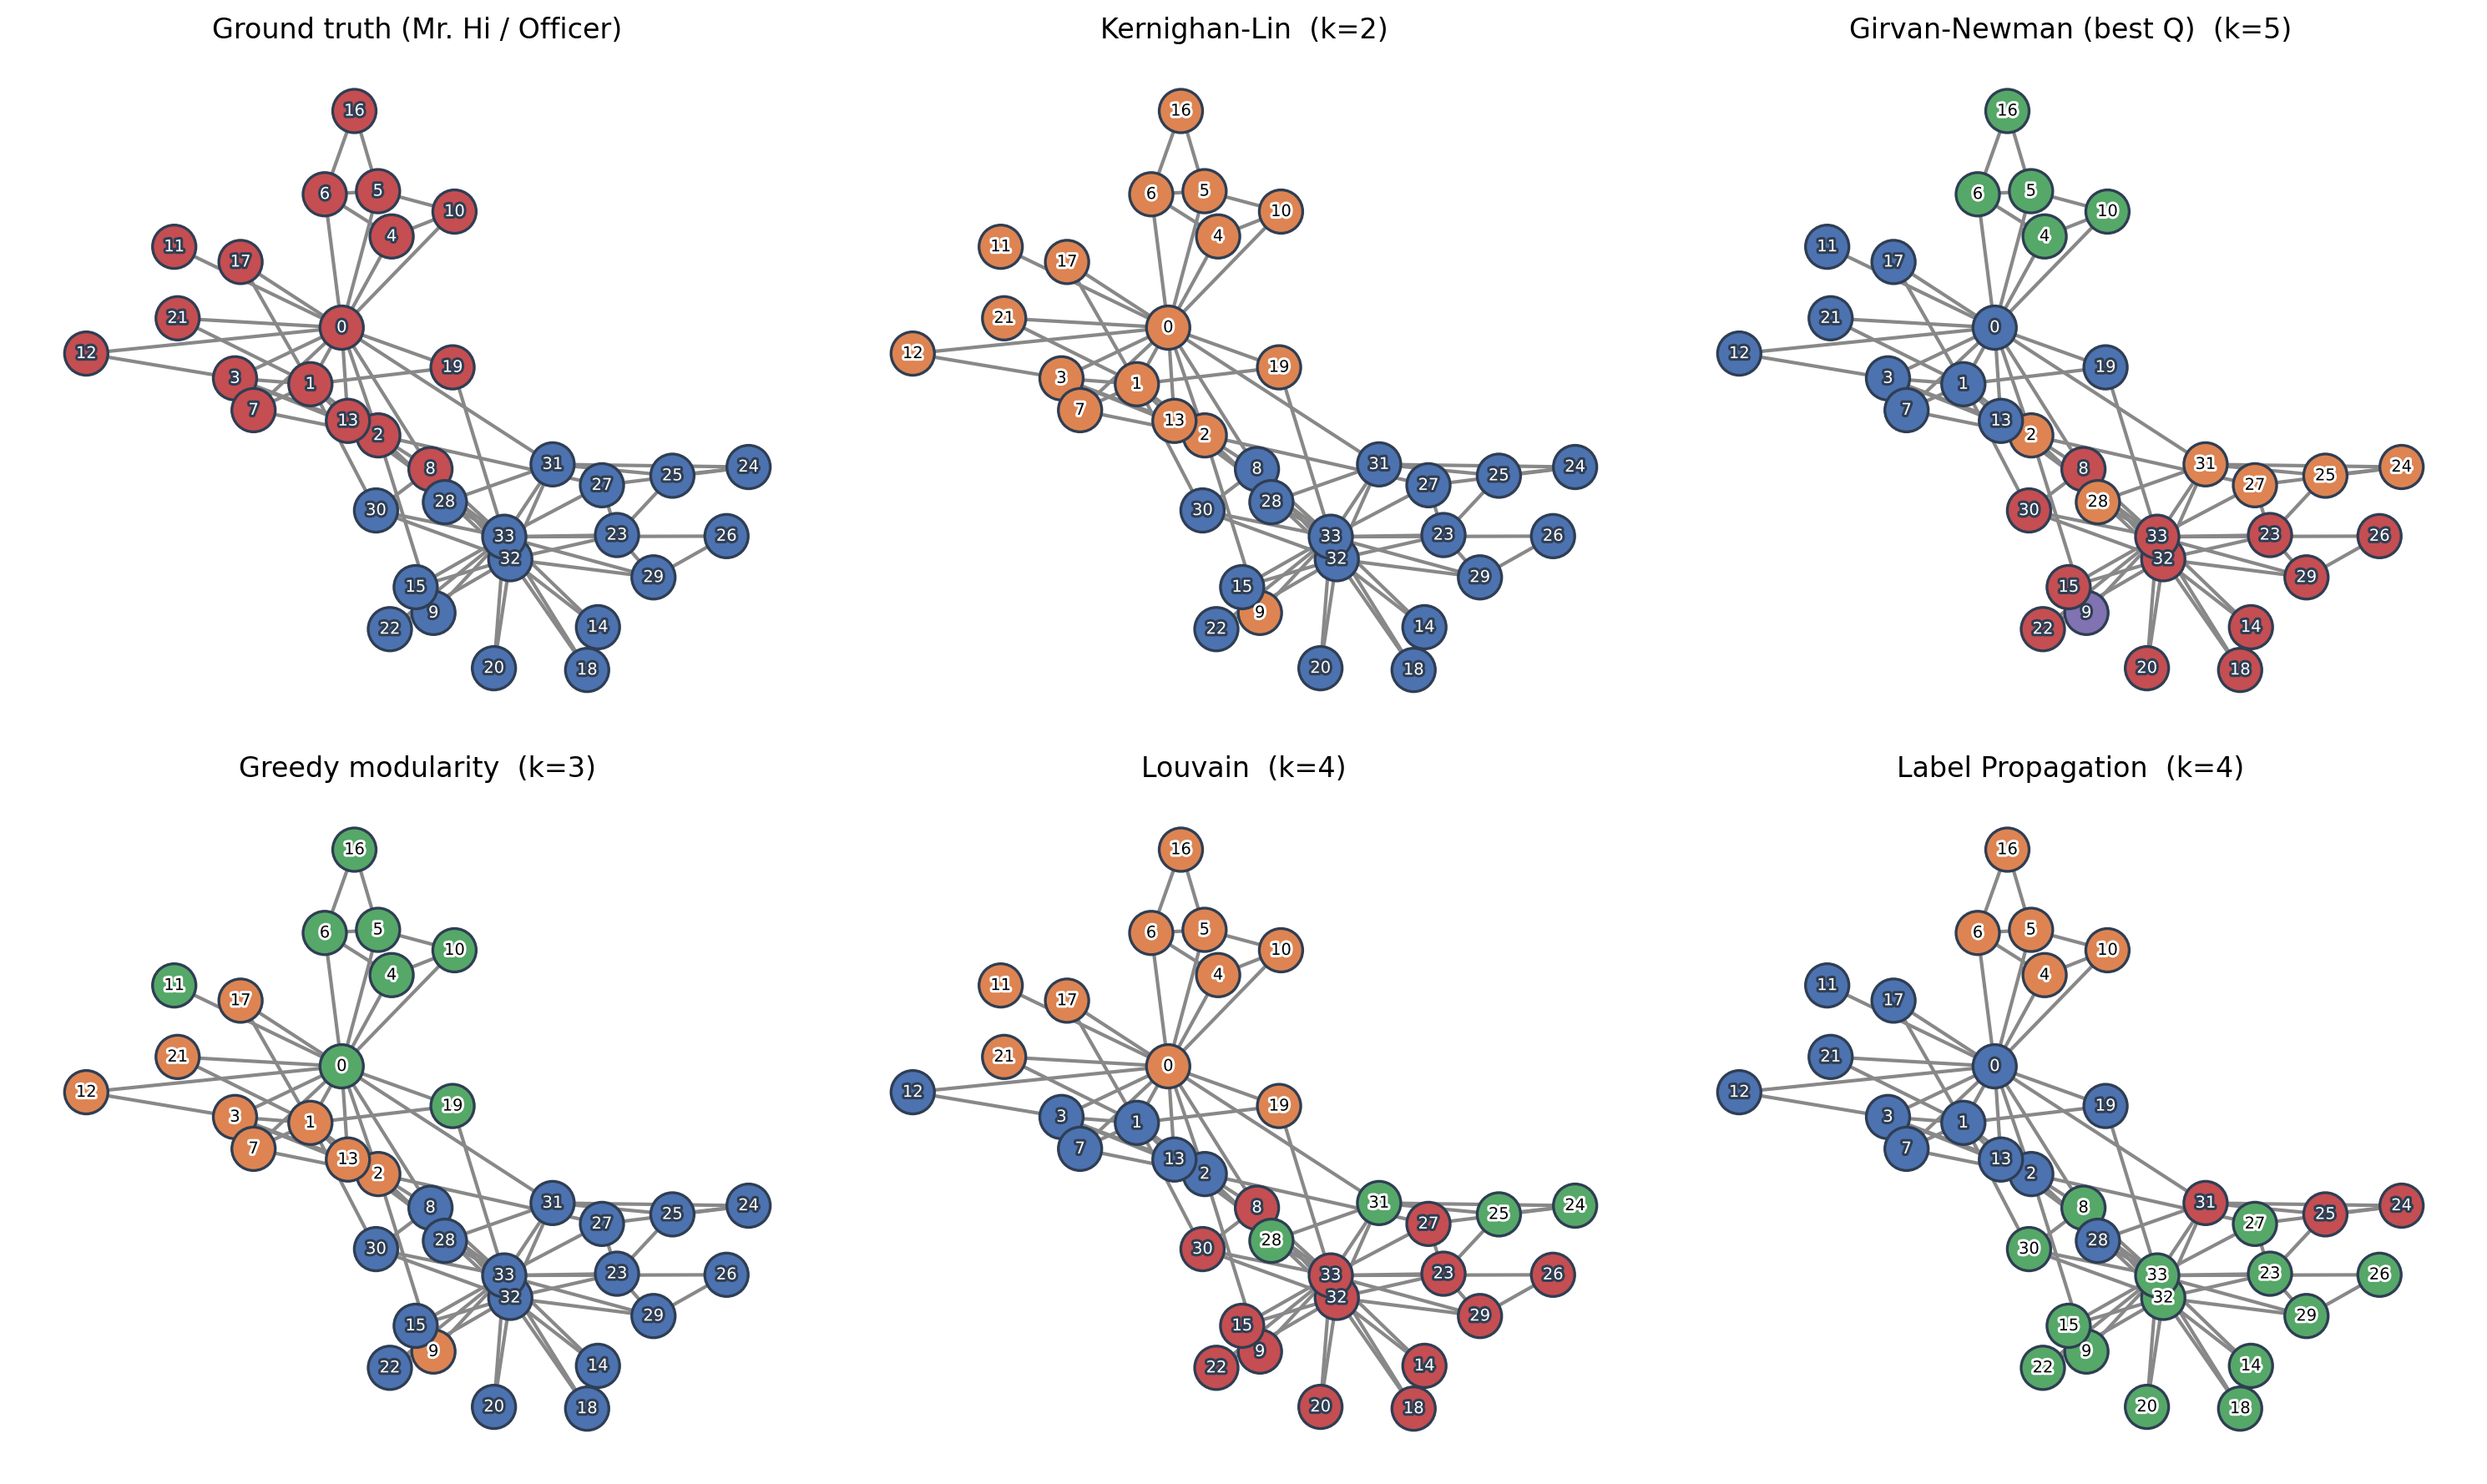

In [24]:
# 2x3 side-by-side partition visualisations on the same layout
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

ref_colors = [CATEGORY_PALETTE['red'] if karate_truth[n] == 0 else CATEGORY_PALETTE['blue']
              for n in G_karate.nodes()]
draw_graph(G_karate, pos=pos_karate, ax=axes[0], node_color=ref_colors, node_size=350, font_size=7)
axes[0].set_title('Ground truth (Mr. Hi / Officer)')

for ax, (name, comms) in zip(axes[1:], bench.items()):
    lab_map = {v: cid for cid, C in enumerate(comms) for v in C}
    colors = [palette[lab_map[n] % len(palette)] for n in G_karate.nodes()]
    draw_graph(G_karate, pos=pos_karate, ax=ax, node_color=colors, node_size=350, font_size=7)
    ax.set_title(f'{name}  (k={len(comms)})')
plt.tight_layout(); plt.show()

/var/folders/dy/m471zxc92yg3d_nmckq9dd000000gn/T/ipykernel_82132/2770729527.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_bench_karate['algorithm'], rotation=20, ha='right')


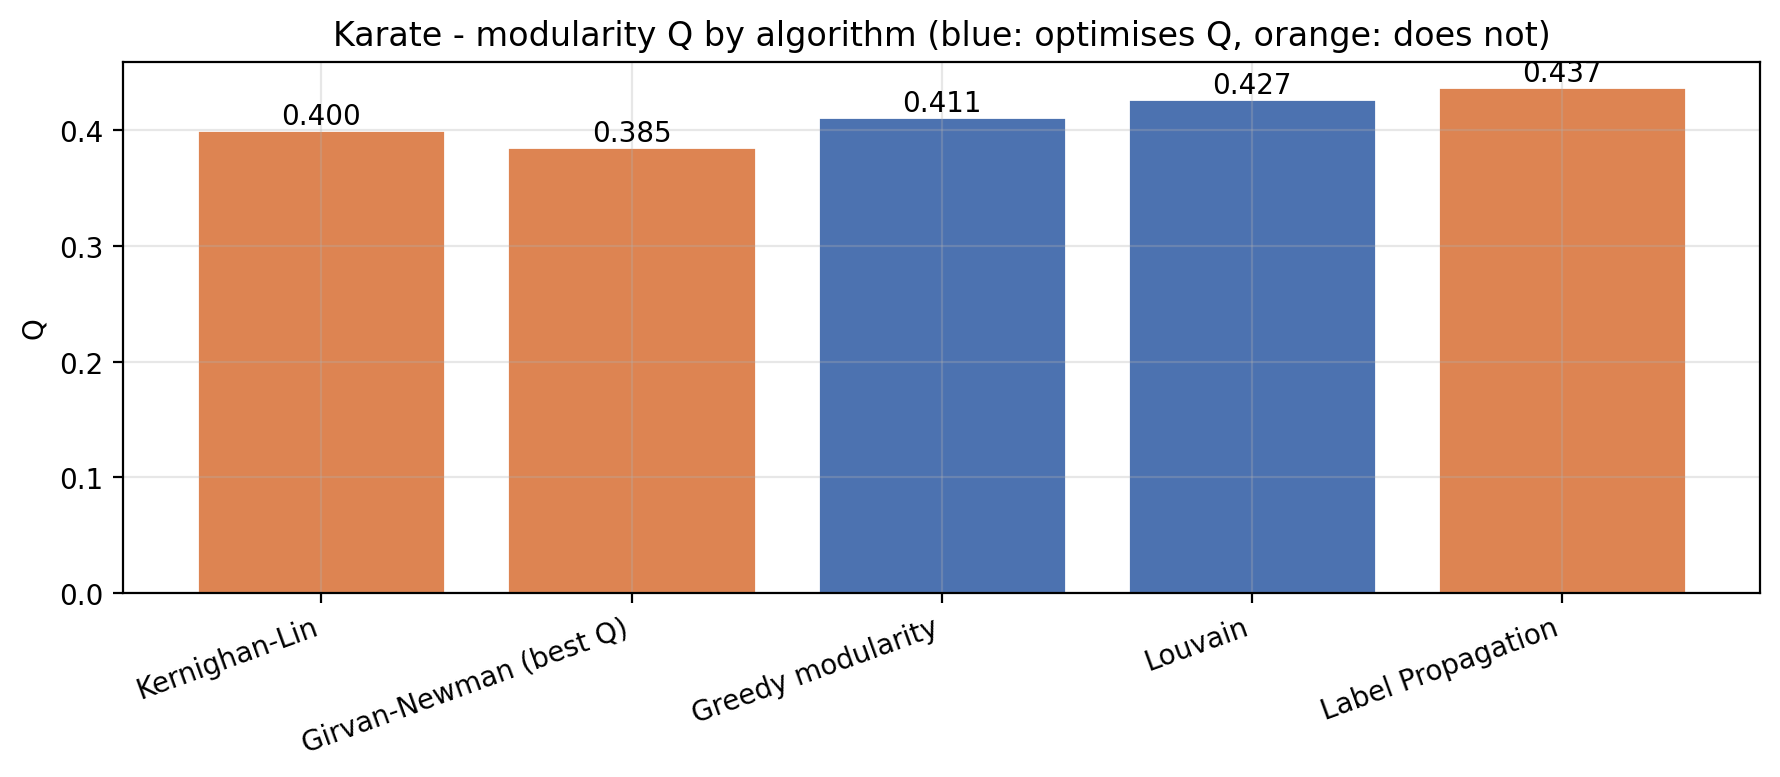

Highest Q:   Label Propagation  (Q=0.437, NMI=0.506)
Highest NMI: Kernighan-Lin (Q=0.4, NMI=0.677)


In [25]:
# Q bar chart coloured by whether the algorithm optimises Q directly
optimises_Q = {'Kernighan-Lin': False, 'Girvan-Newman (best Q)': False,
               'Greedy modularity': True, 'Louvain': True, 'Label Propagation': False}
bar_colors = [CATEGORY_PALETTE['blue'] if optimises_Q[n] else CATEGORY_PALETTE['orange']
              for n in df_bench_karate['algorithm']]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(df_bench_karate['algorithm'], df_bench_karate['Q'], color=bar_colors, edgecolor='white')
for i, v in enumerate(df_bench_karate['Q']):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center')
ax.set_xticklabels(df_bench_karate['algorithm'], rotation=20, ha='right')
style_axis(ax, title='Karate - modularity Q by algorithm (blue: optimises Q, orange: does not)',
           xlabel='', ylabel='Q')
plt.tight_layout(); plt.show()

best_Q_row   = df_bench_karate.loc[df_bench_karate['Q'].idxmax()]
best_NMI_row = df_bench_karate.loc[df_bench_karate['NMI vs truth'].idxmax()]
print(f"Highest Q:   {best_Q_row['algorithm']}  (Q={best_Q_row['Q']}, NMI={best_Q_row['NMI vs truth']})")
print(f"Highest NMI: {best_NMI_row['algorithm']} (Q={best_NMI_row['Q']}, NMI={best_NMI_row['NMI vs truth']})")

**Interpretation.** The algorithm with the **highest $Q$** is not always the one that best recovers the **ground truth**. Louvain and Greedy push $Q$ slightly higher than the ground-truth partition's own $Q$ - they *over-split* to accrue more modularity, a direct symptom of the resolution limit we will demonstrate in Section 10. Kernighan-Lin, constrained to $k=2$, lands closest to the faction split precisely because it was told to find a bisection.

---
## 10. Benchmark - Les Miserables (no ground truth)

Without a reference we cannot evaluate *correctness*. We can however quantify **agreement** between algorithms and identify the **stable core** of the community structure.

In [26]:
lm_algos = {
    'Kernighan-Lin':       kl_partition(G_lesmis, RANDOM_SEED),
    'Girvan-Newman':       gn_best_Q(G_lesmis, max_levels=20),
    'Greedy modularity':   list(nx.community.greedy_modularity_communities(G_lesmis)),
    'Louvain':             nx.community.louvain_communities(G_lesmis, seed=RANDOM_SEED),
    'Label Propagation':   lp_networkx_partition(G_lesmis, seed=RANDOM_SEED),
}
rows = []
for name, comms in lm_algos.items():
    rows.append({'algorithm': name, 'k': len(comms),
                 'Q': round(nx.community.modularity(G_lesmis, comms), 3)})
display(pd.DataFrame(rows))

,algorithm,k,Q
0,Kernighan-Lin,2,0.356
1,Girvan-Newman,11,0.478
2,Greedy modularity,5,0.473
3,Louvain,6,0.565
4,Label Propagation,6,0.337


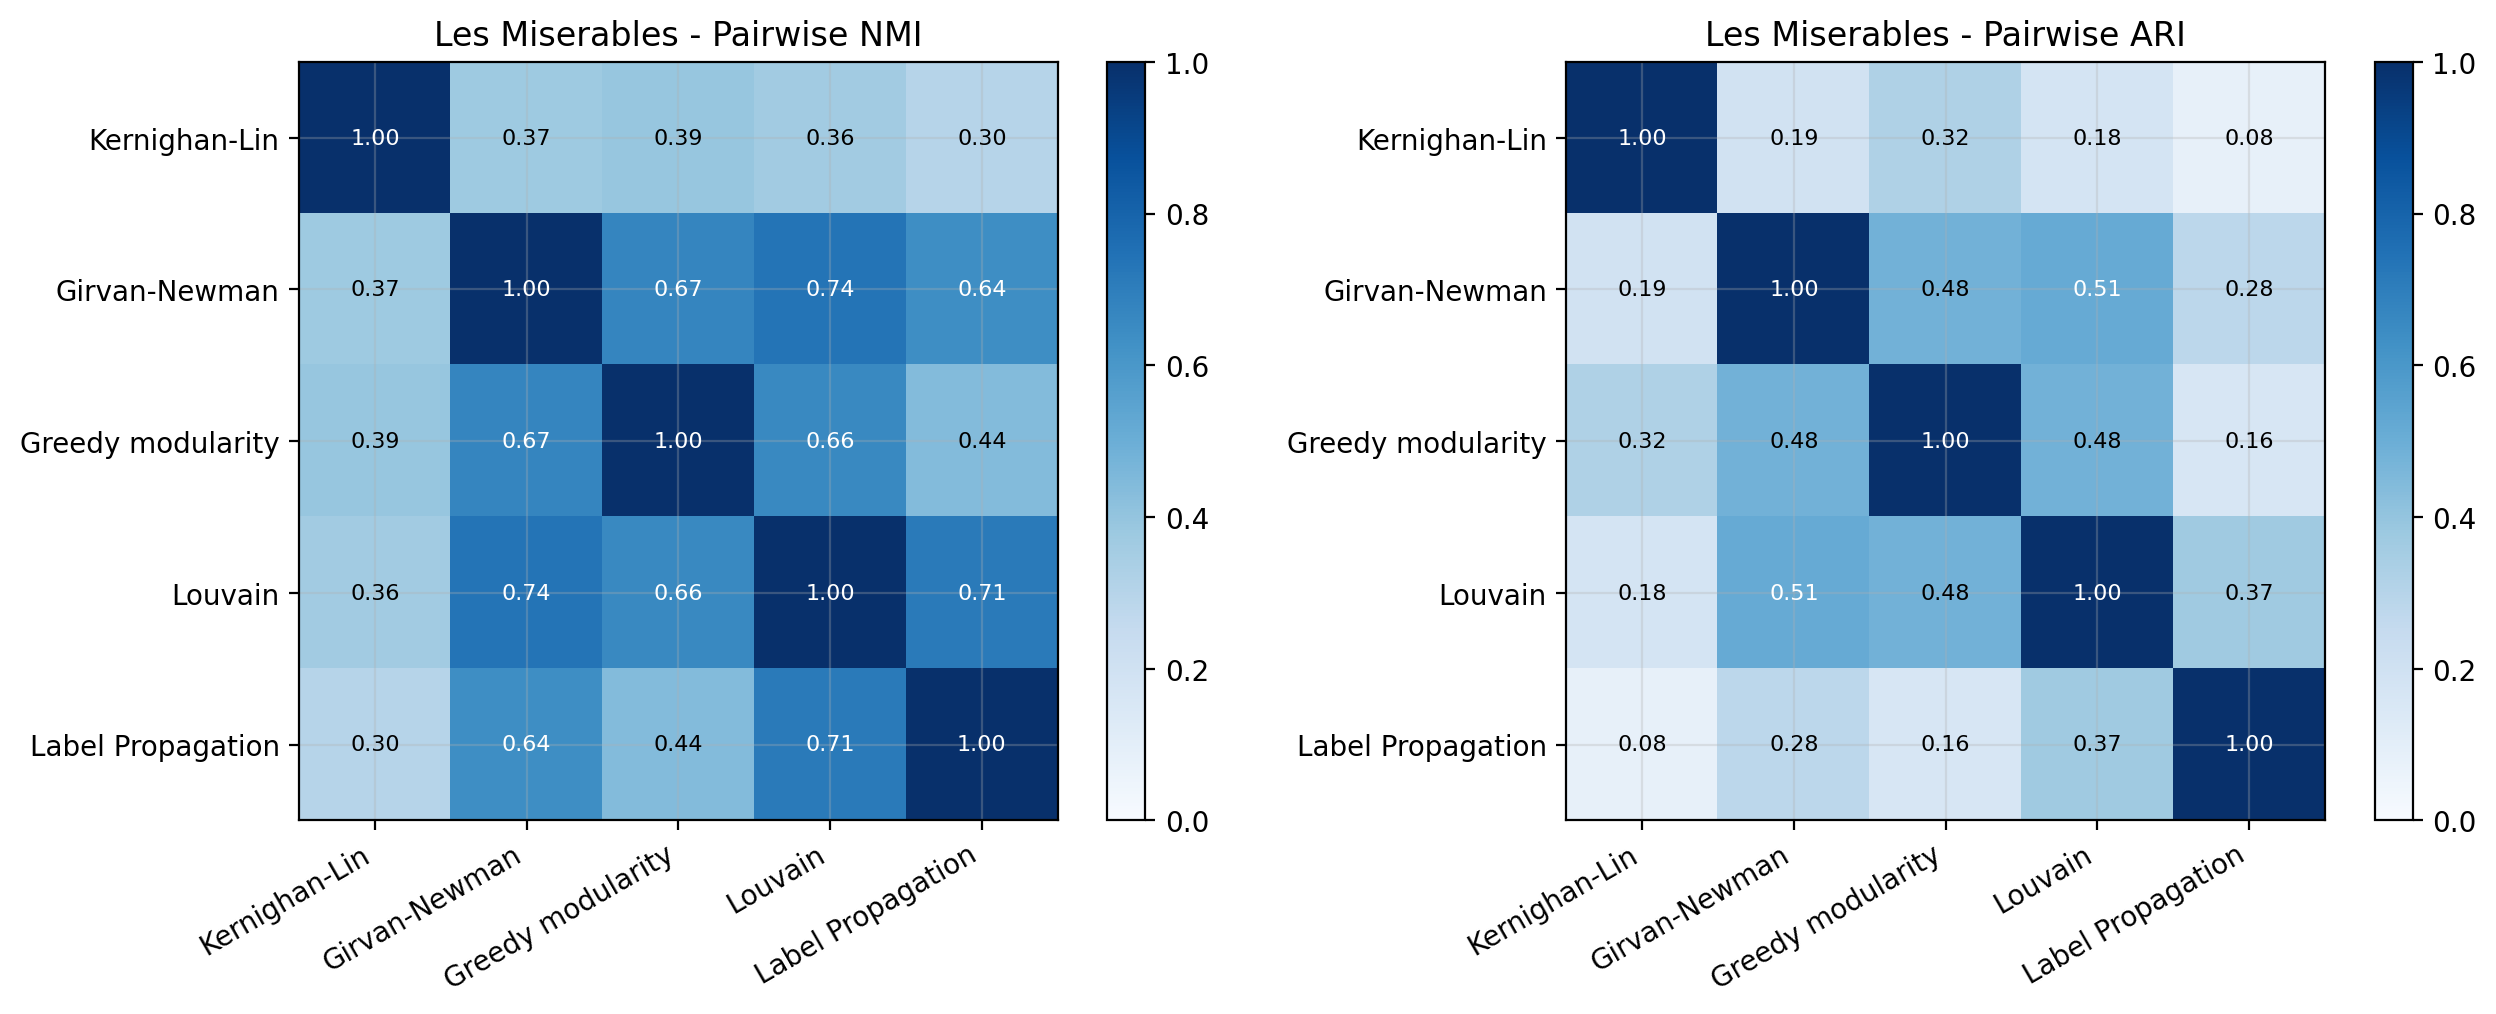

In [27]:
names = list(lm_algos.keys())
labels_list = [partition_to_labels(G_lesmis, lm_algos[n]) for n in names]
M_nmi = np.ones((len(names), len(names)))
M_ari = np.ones((len(names), len(names)))
for i in range(len(names)):
    for j in range(i+1, len(names)):
        M_nmi[i, j] = M_nmi[j, i] = normalized_mutual_info_score(labels_list[i], labels_list[j])
        M_ari[i, j] = M_ari[j, i] = adjusted_rand_score(labels_list[i], labels_list[j])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title in [(axes[0], M_nmi, 'Pairwise NMI'), (axes[1], M_ari, 'Pairwise ARI')]:
    im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=30, ha='right')
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if mat[i,j] > 0.5 else 'black')
    ax.set_title(f'Les Miserables - {title}')
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

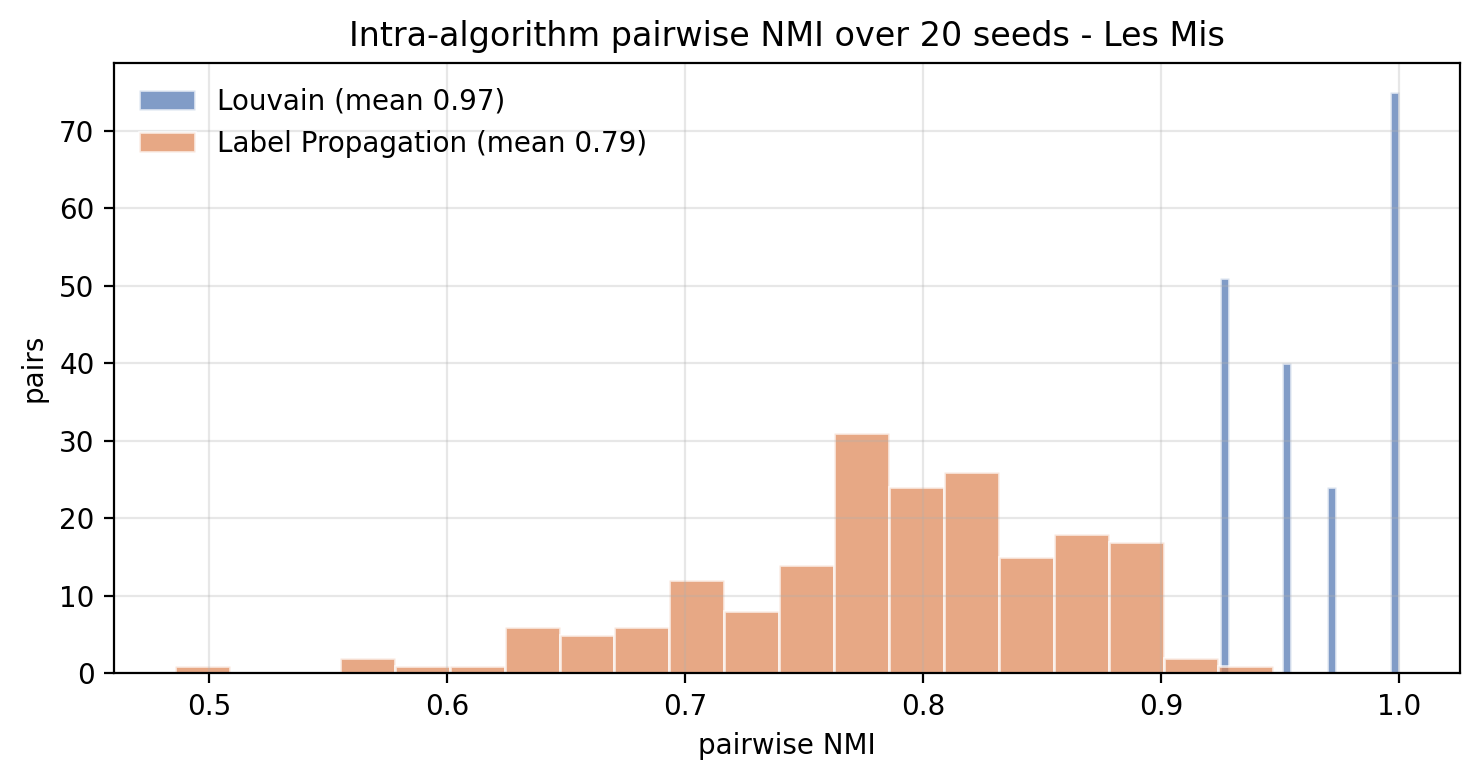

In [28]:
# Intra-algorithm instability: 20 runs of Louvain and LP
louvain_runs = [nx.community.louvain_communities(G_lesmis, seed=s) for s in range(20)]
lp_runs      = [lp_networkx_partition(G_lesmis, seed=s) for s in range(20)]

def pairwise_nmi_list(runs, G):
    labs = [partition_to_labels(G, r) for r in runs]
    vals = []
    for i in range(len(labs)):
        for j in range(i+1, len(labs)):
            vals.append(normalized_mutual_info_score(labs[i], labs[j]))
    return np.array(vals)

nmi_louv = pairwise_nmi_list(louvain_runs, G_lesmis)
nmi_lp   = pairwise_nmi_list(lp_runs,      G_lesmis)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(nmi_louv, bins=20, alpha=0.7, color=CATEGORY_PALETTE['blue'],
        edgecolor='white', label=f'Louvain (mean {nmi_louv.mean():.2f})')
ax.hist(nmi_lp,   bins=20, alpha=0.7, color=CATEGORY_PALETTE['orange'],
        edgecolor='white', label=f'Label Propagation (mean {nmi_lp.mean():.2f})')
style_axis(ax, title='Intra-algorithm pairwise NMI over 20 seeds - Les Mis',
           xlabel='pairwise NMI', ylabel='pairs', legend=True)
plt.show()

In [29]:
# Stable core vs boundary: co-occurrence over ALL 40 runs (20 Louvain + 20 LP)
all_runs = louvain_runs + lp_runs
nodes = list(G_lesmis.nodes())
idx = {n: i for i, n in enumerate(nodes)}
N = len(nodes)
co = np.zeros((N, N))
for comms in all_runs:
    for C in comms:
        C = list(C)
        for u in C:
            for v in C:
                co[idx[u], idx[v]] += 1
co /= len(all_runs)

# For each node, measure agreement stability: mean co-occurrence with its most-frequent partners
stability = co.mean(axis=1)
order = np.argsort(-stability)
stable_top = [nodes[i] for i in order[:8]]
fickle_top = [nodes[i] for i in order[-8:]]
print('Most stable (always co-clustered with similar partners):', stable_top)
print('Most fickle (boundary characters):                        ', fickle_top)

Most stable (always co-clustered with similar partners): ['Cosette', 'Toussaint', 'Woman2', 'Javert', 'Scaufflaire', 'Gervais', 'Isabeau', 'MmeDeR']
Most fickle (boundary characters):                         ['Fameuil', 'Listolier', 'Brevet', 'Bamatabois', 'Judge', 'Champmathieu', 'Chenildieu', 'Cochepaille']


**Interpretation.** Modularity-based methods (Greedy, Louvain) agree strongly with each other - unsurprisingly, they optimise the same objective. LP typically finds a *finer* partition. The *stable core* characters are those at the centre of a well-defined subplot (the protagonist's inner circle, the barricade group); the *fickle* characters are those connecting multiple subplots - messengers, sparsely-connected side characters - whose community assignment depends on where the algorithm draws the boundary.

---
## 11. Modularity's limits revisited - deeper

### 11.1 The resolution limit with `ring_of_cliques`

Fortunato & Barthelemy (2007) showed that modularity maximisation **cannot detect** communities smaller than a scale set by the total number of edges $L$:
$$\text{communities with fewer than } \sqrt{L/2} \text{ internal links are undetectable.}$$

The classic demonstration is a **ring of cliques**: $k$ cliques of size $s$ arranged on a ring and connected by single bridge edges. The ground truth is obvious - each clique is a community - yet modularity-based methods *merge* adjacent cliques into pairs because each merger raises $Q$.

**Three pathologies, one root cause.** Every limitation in this section comes from the same fact: modularity $Q$ is a *single scalar* that has to summarise an exponentially large set of partitions. That summary inevitably loses information, and the loss surfaces in three concrete ways:

1. **Resolution limit (§11.1)** — communities below the $\sqrt{L}$ scale are absorbed into larger groups. *Symptom:* big planted cliques are merged.
2. **Degeneracy (§11.2)** — many very different partitions sit on a near-flat $Q$ plateau, so the "best" partition is **not unique**. *Symptom:* re-running Louvain returns inconsistent partitions at almost identical $Q$.
3. **Non-comparability (§11.3)** — the $Q$ achievable on a network depends on its size and density, so a higher $Q$ on network $A$ does not mean network $A$ has clearer community structure than network $B$. *Symptom:* a random Erdős–Rényi graph attains $Q \approx 0.4$ even though it has no planted communities.

Each subsection picks one pathology, builds the smallest possible demonstration of it, and ends with a practical recommendation.

In [30]:
ring_sizes = [6, 10, 16, 24, 40]
ring_rows = []
for k in ring_sizes:
    G_r = nx.ring_of_cliques(num_cliques=k, clique_size=5)
    L   = G_r.number_of_edges()
    comms_l = nx.community.louvain_communities(G_r, seed=RANDOM_SEED)
    comms_lp = lp_networkx_partition(G_r, seed=RANDOM_SEED)
    ring_rows.append({
        'true_k': k,
        'L': L,
        'sqrt_2L': round(np.sqrt(2 * L), 2),
        'Louvain_k': len(comms_l),
        'LP_k': len(comms_lp),
    })
df_ring = pd.DataFrame(ring_rows)
display(df_ring)

,true_k,L,sqrt_2L,Louvain_k,LP_k
0,6,66,11.49,6,6
1,10,110,14.83,10,10
2,16,176,18.76,16,16
3,24,264,22.98,14,24
4,40,440,29.66,23,40


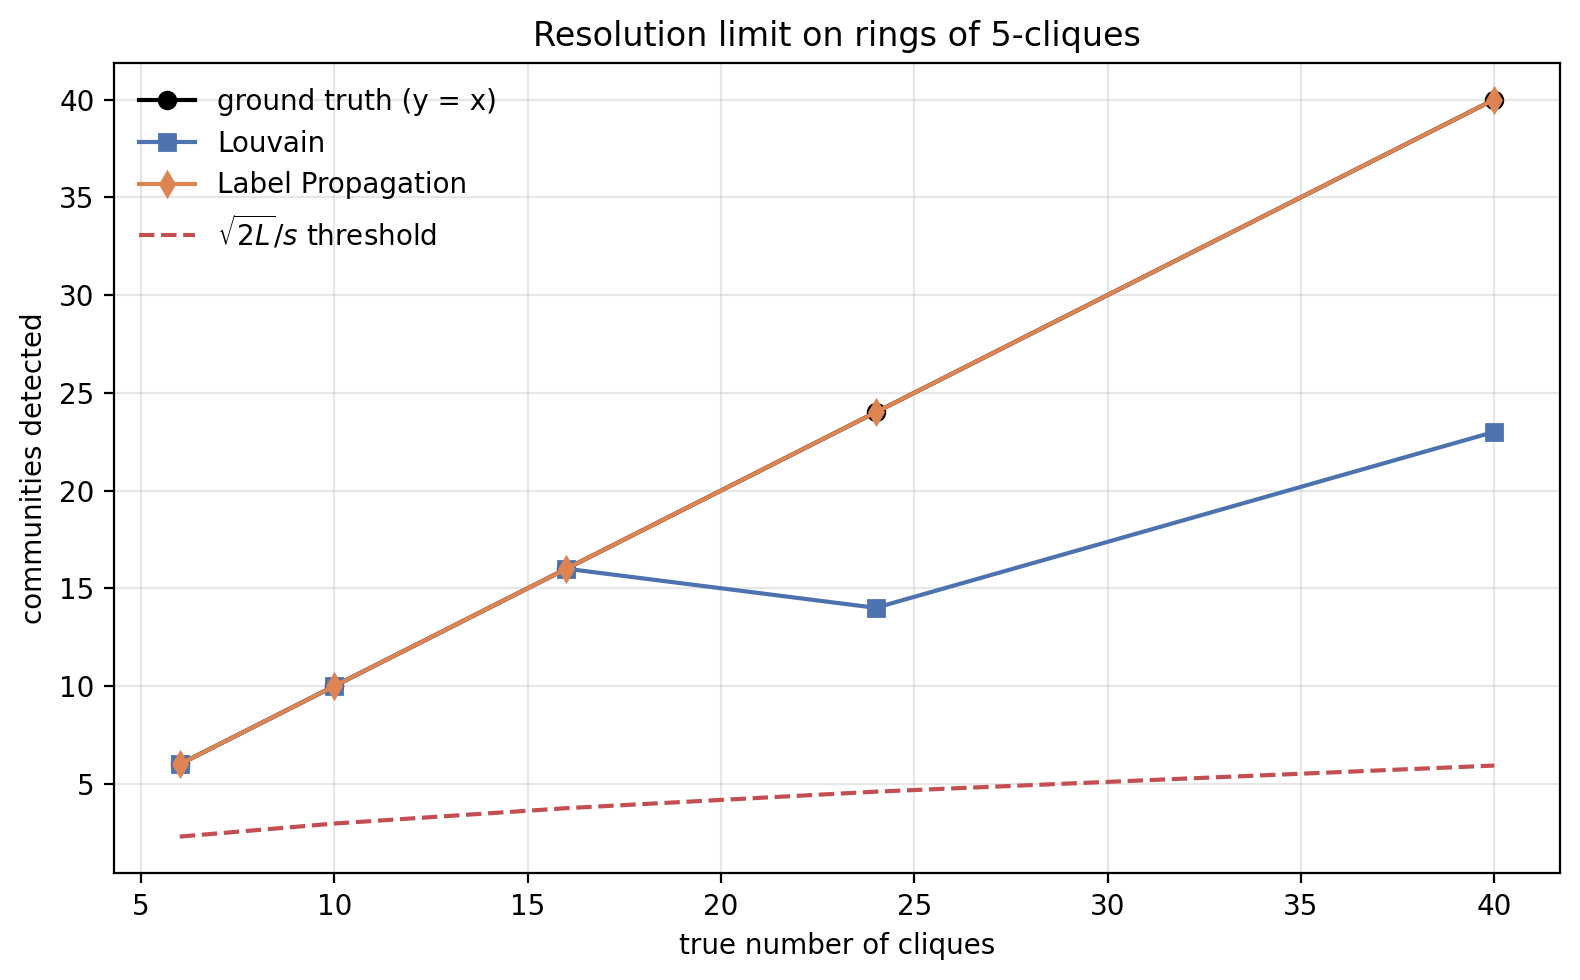

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_ring['true_k'], df_ring['true_k'],      'o-', color='black',
        label='ground truth (y = x)')
ax.plot(df_ring['true_k'], df_ring['Louvain_k'],   's-', color=CATEGORY_PALETTE['blue'],
        label='Louvain')
ax.plot(df_ring['true_k'], df_ring['LP_k'],        'd-', color=CATEGORY_PALETTE['orange'],
        label='Label Propagation')
# Overlay the sqrt(2L) threshold (translated to "detectable k")
ax.plot(df_ring['true_k'], df_ring['sqrt_2L'] / 5, '--', color=CATEGORY_PALETTE['red'],
        label=r'$\sqrt{2L}/s$ threshold')
style_axis(ax, title='Resolution limit on rings of 5-cliques',
           xlabel='true number of cliques', ylabel='communities detected', legend=True)
plt.show()

**Observation.** Louvain under-reports communities as the ring grows - it merges adjacent cliques in pairs to push $Q$ slightly higher. LP, which does not optimise $Q$, tracks the ground truth much more closely. This is concrete evidence that *modularity's best solution is not always the sensible one*.

### 11.2 Degeneracy - the flat plateau

Good & de Montjoye (2010) showed that the modularity landscape typically has a **huge number of near-optimal partitions**, whose $Q$ values sit within a tiny window. This is **degeneracy**: many solutions are essentially indistinguishable by $Q$, yet they disagree on the actual node assignments. We rerun Louvain 30 times on Les Mis and measure both.

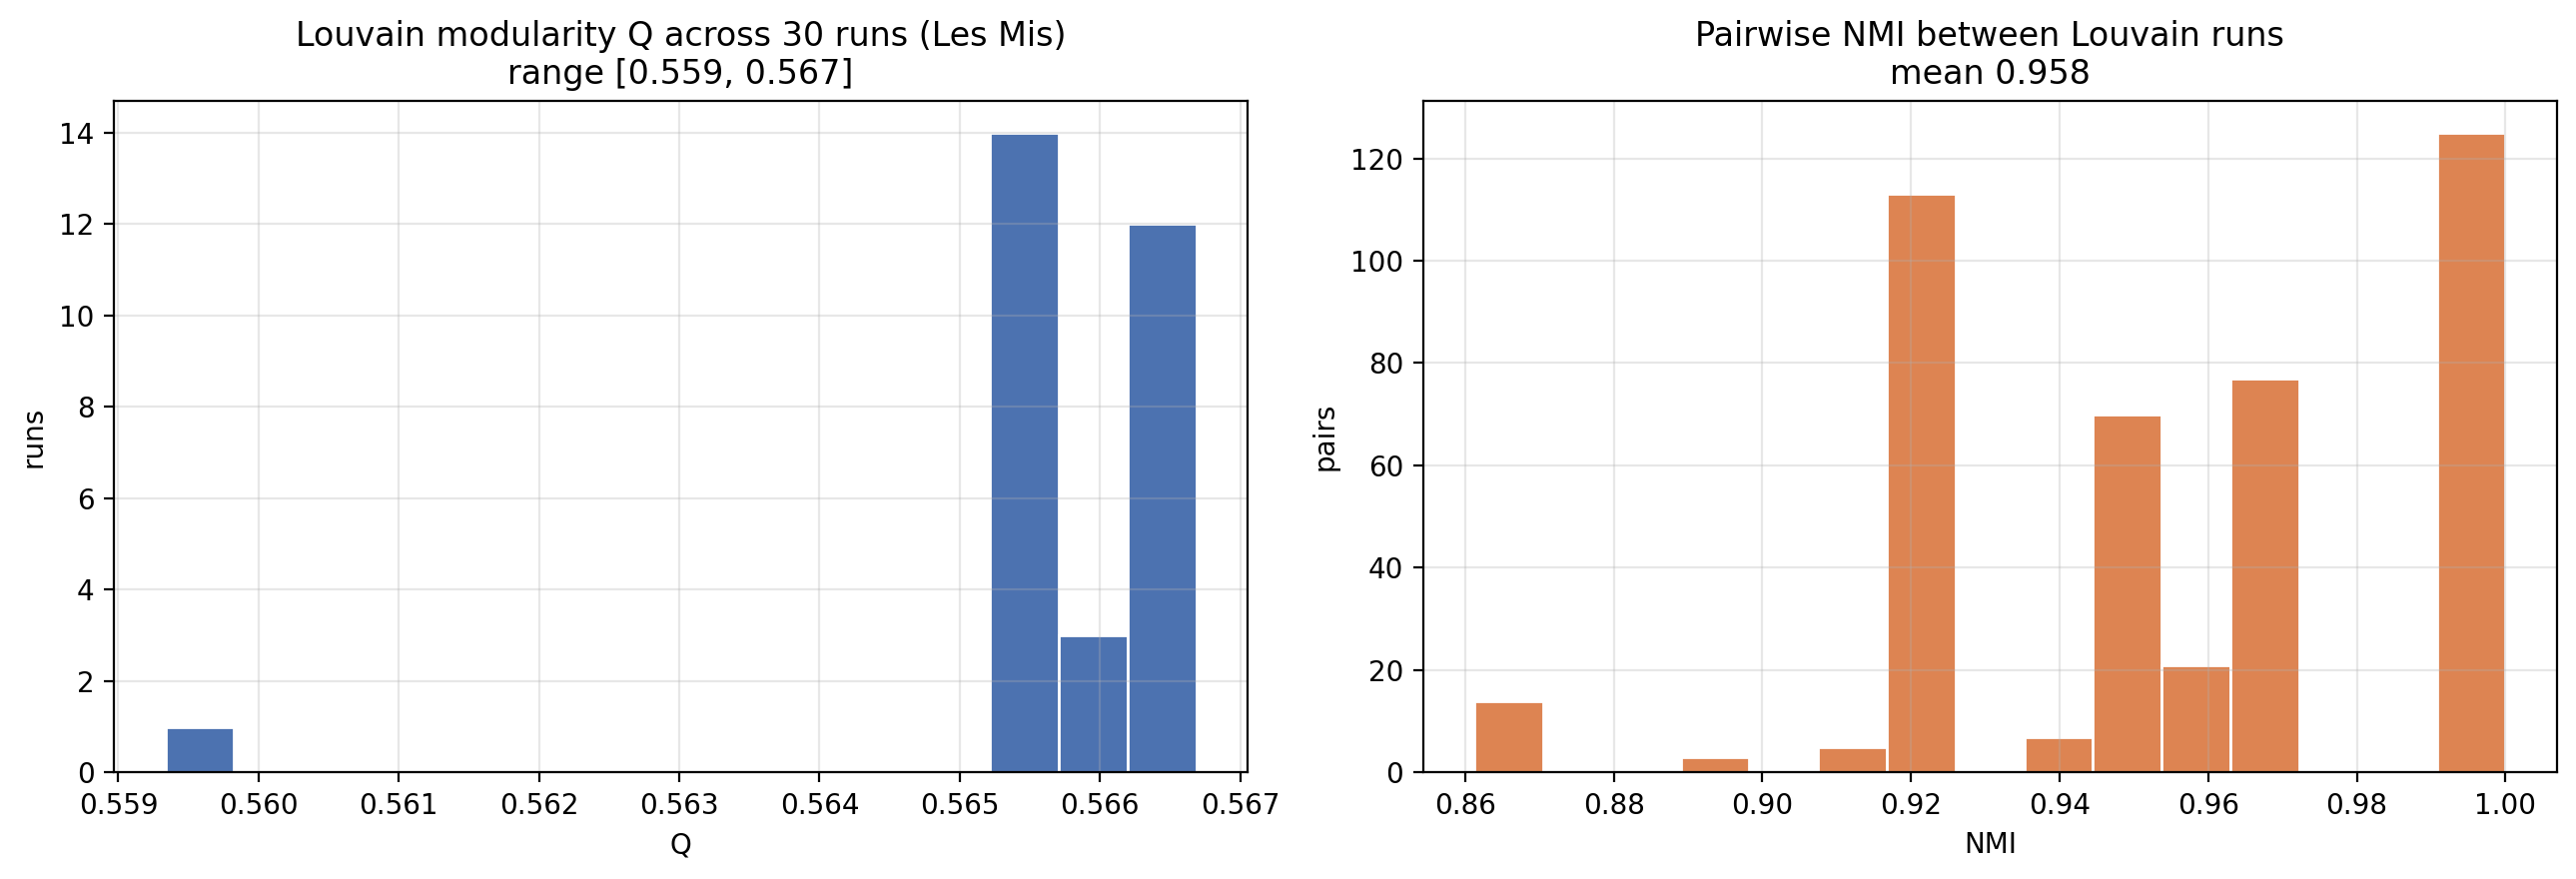

In [32]:
partitions_lm = []
Qs = []
for s in range(30):
    comms = nx.community.louvain_communities(G_lesmis, seed=s)
    partitions_lm.append(partition_to_labels(G_lesmis, comms))
    Qs.append(nx.community.modularity(G_lesmis, comms))

R = len(partitions_lm)
nmi_matrix = np.ones((R, R))
for i in range(R):
    for j in range(i+1, R):
        v = normalized_mutual_info_score(partitions_lm[i], partitions_lm[j])
        nmi_matrix[i, j] = nmi_matrix[j, i] = v
upper = nmi_matrix[np.triu_indices(R, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(Qs, bins=15, color=CATEGORY_PALETTE['blue'], edgecolor='white')
style_axis(axes[0], title=f'Louvain modularity Q across 30 runs (Les Mis)\nrange [{min(Qs):.3f}, {max(Qs):.3f}]',
           xlabel='Q', ylabel='runs')
axes[1].hist(upper, bins=15, color=CATEGORY_PALETTE['orange'], edgecolor='white')
style_axis(axes[1], title=f'Pairwise NMI between Louvain runs\nmean {upper.mean():.3f}',
           xlabel='NMI', ylabel='pairs')
plt.show()

In [33]:
# Co-occurrence across the 30 Louvain runs - identify fickle characters
nodes = list(G_lesmis.nodes())
idx = {n: i for i, n in enumerate(nodes)}
N = len(nodes)
co = np.zeros((N, N))
for s in range(30):
    comms = nx.community.louvain_communities(G_lesmis, seed=s)
    for C in comms:
        C = list(C)
        for u in C:
            for v in C:
                co[idx[u], idx[v]] += 1
co /= 30

# 'fickleness' = entropy of a node's row (probability of being in the same community as each partner)
row_p = co / co.sum(axis=1, keepdims=True)
row_ent = -np.nansum(np.where(row_p > 0, row_p * np.log(row_p), 0), axis=1)
rank = np.argsort(-row_ent)
fickle_names = [nodes[i] for i in rank[:10]]
stable_names = [nodes[i] for i in rank[-10:]]
print('Top 10 FICKLE characters (community changes most across Louvain seeds):')
print(fickle_names)
print('Top 10 STABLE characters:')
print(stable_names)

Top 10 FICKLE characters (community changes most across Louvain seeds):
['Magnon', 'Perpetue', 'Simplice', 'Fauchelevent', 'Javert', 'Cosette', 'Pontmercy', 'Woman2', 'MotherInnocent', 'Gribier']
Top 10 STABLE characters:
['CountessDeLo', 'MmeMagloire', 'MlleBaptistine', 'Myriel', 'Brevet', 'Champmathieu', 'Judge', 'Bamatabois', 'Chenildieu', 'Cochepaille']


/var/folders/dy/m471zxc92yg3d_nmckq9dd000000gn/T/ipykernel_82132/168881895.py:17: RuntimeWarning: divide by zero encountered in log
  row_ent = -np.nansum(np.where(row_p > 0, row_p * np.log(row_p), 0), axis=1)
/var/folders/dy/m471zxc92yg3d_nmckq9dd000000gn/T/ipykernel_82132/168881895.py:17: RuntimeWarning: invalid value encountered in multiply
  row_ent = -np.nansum(np.where(row_p > 0, row_p * np.log(row_p), 0), axis=1)


**Degeneracy in action.** $Q$ barely moves across 30 runs (the **flat plateau**), yet NMI distributions show the partitions *are not* identical. Reporting a single Louvain partition without this diagnostic is misleading - the community assignment of some characters is essentially a coin flip among the near-optima.

### 11.3 Cross-network comparability of $Q$

A tempting mistake: reading $Q$ as an absolute score. We compare the max $Q$ on four networks to show this is wrong.

/var/folders/dy/m471zxc92yg3d_nmckq9dd000000gn/T/ipykernel_82132/1219424729.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(Qs_by_net), rotation=15, ha='right')


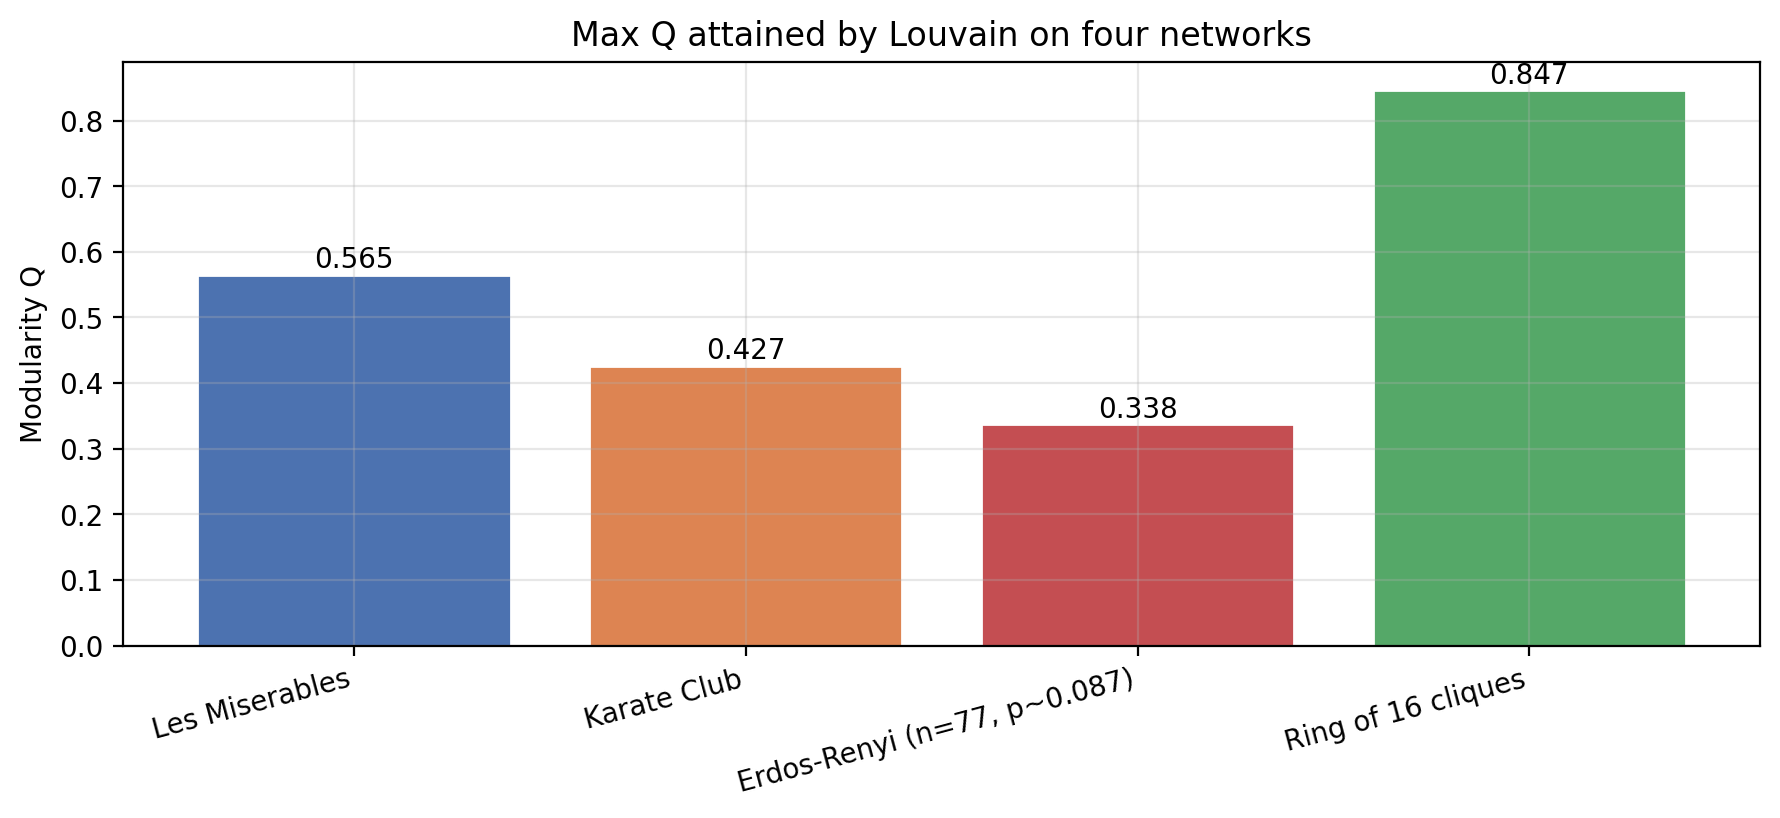

An ER graph has NO designed community structure yet attains a non-trivial Q.
Q is therefore NOT comparable across networks - it must be contextualised by a null model.


In [34]:
# ER graph of matched size and density for Les Mis
n_lm = G_lesmis.number_of_nodes(); p_lm = nx.density(G_lesmis)
G_er = nx.erdos_renyi_graph(n_lm, p_lm, seed=RANDOM_SEED)
if not nx.is_connected(G_er):
    G_er = G_er.subgraph(max(nx.connected_components(G_er), key=len)).copy()
G_ring_ref = nx.ring_of_cliques(num_cliques=16, clique_size=5)

nets = {
    'Les Miserables':              G_lesmis,
    'Karate Club':                 G_karate,
    f'Erdos-Renyi (n={n_lm}, p~{p_lm:.3f})': G_er,
    'Ring of 16 cliques':          G_ring_ref,
}
Qs_by_net = {}
for name, G in nets.items():
    comms = nx.community.louvain_communities(G, seed=RANDOM_SEED)
    Qs_by_net[name] = nx.community.modularity(G, comms)

fig, ax = plt.subplots(figsize=(9, 4.2))
col = [CATEGORY_PALETTE['blue'], CATEGORY_PALETTE['orange'],
       CATEGORY_PALETTE['red'],  CATEGORY_PALETTE['green']]
ax.bar(list(Qs_by_net), list(Qs_by_net.values()), color=col, edgecolor='white')
for i, v in enumerate(Qs_by_net.values()):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center')
ax.set_xticklabels(list(Qs_by_net), rotation=15, ha='right')
style_axis(ax, title='Max Q attained by Louvain on four networks',
           xlabel='', ylabel='Modularity Q')
plt.tight_layout(); plt.show()

print('An ER graph has NO designed community structure yet attains a non-trivial Q.')
print('Q is therefore NOT comparable across networks - it must be contextualised by a null model.')

**Takeaway.** $Q$ is a *within-network* score. Comparing $Q$ of Les Mis with $Q$ of a different-size, different-density graph is meaningless. To compare across networks one must rescale - e.g. use $Q/Q_{\text{max,null}}$ - or switch to an information-theoretic baseline (SBM log-likelihood, description length).

---
## 12. Decision guide - when to use which algorithm

| Method | Sweet spot | Watch out for |
|---|---|---|
| **Kernighan-Lin** | balanced cuts with a *known* $k$; VLSI circuit placement, parallel-task allocation | not a community detector; strong init dependence |
| **Girvan-Newman** | small-to-medium networks where an interpretable *dendrogram* matters | $\mathcal{O}(NM^2)$; impractical above ~10k nodes |
| **Greedy / CNM** | medium networks; fast first-pass modularity | local optima; resolution limit |
| **Louvain** | millions of nodes; natural hierarchy; high $Q$ | degeneracy, order-dependence, resolution limit |
| **Label Propagation** | huge sparse graphs; semi-supervised seeding; consensus across runs | instability, tie-breaking randomness, fails on bipartite-like structures |

### Use-case anecdotes

- *Circuit partitioning* - fixed $k$, balanced cut, runtime irrelevant: **KL**.
- *Small academic graph with interpretable story* (Karate, Dolphins): **GN** for the dendrogram, **Louvain** for a single partition.
- *Million-node social network*: **Louvain** (scalability + multiscale).
- *Billion-edge web graph with partial labels*: **semi-supervised LP**.
- *Need the hierarchy*: GN (top-down) or Louvain (bottom-up).
- *Need stability across runs more than raw speed*: consensus over 50 Louvain or LP runs.

### Decision flowchart (text form)

```
    Known k? -> yes -> Balanced cut needed? -> KL
               |               |
               |               no -> spectral methods / SBM
               |
               no
               |
    Hierarchy wanted? -> yes -> Small/med network -> GN
                     |                |
                     |                Large network -> Louvain
                     |
                     no
                     |
    Some labels known? -> yes -> semi-supervised LP
                     |
                     no
                     |
    Graph huge & sparse? -> yes -> LP (+ consensus)
                        |
                        no  -> Louvain (+ report NMI across seeds)
```

---
## 13. Exercises

### Exercise 1 - Synchronous vs asynchronous LP

Implement a **synchronous** variant of LP in which every node updates simultaneously based on the labels *at the end of the previous sweep*. Run 50 times on Karate with sync and 50 with async. Compare:
- distribution of the number of sweeps,
- distribution of $k$ and $Q$,
- pairwise NMI between runs.

**Expected finding.** Synchronous LP often fails to converge - it oscillates between two symmetric states on bipartite-like structures. Async is less stable in outcome but reliably stationary. Report your observations.

In [35]:
# Your solution for Exercise 1 goes here.
# Hint: build a copy of the labels dict at the start of each sweep and read from it while writing to a new one.


### Exercise 2 - Davis Southern Women (bipartite-like)

On `nx.davis_southern_women_graph()` run all five algorithms (KL, GN best-Q, Greedy, Louvain, LP) and report:
1. NMI/ARI of each partition vs the known group membership.
2. Pairwise NMI among the five algorithms.
3. A short discussion: does LP's bipartite pitfall (Section 2.4) show up?

In [36]:
# Your solution for Exercise 2 goes here.
# G_dav = nx.davis_southern_women_graph()


### Exercise 3 - Consensus partition on Les Mis

Run LP 50 times on Les Miserables, build the co-occurrence matrix $M$, compute $D = 1 - M$, and run agglomerative clustering on $D$ (use `scipy.cluster.hierarchy.linkage` with `method='average'`). Extract a consensus partition by cutting the dendrogram at $k^* = \mathrm{mode}(k_{\text{LP}})$ clusters.

Compare the modularity of the consensus partition with (i) the median single-LP-run modularity and (ii) Louvain's modularity.

In [37]:
# Your solution for Exercise 3 goes here.


### Exercise 4 - Conceptual

Suppose you run Louvain 10 times on a graph and obtain *the same $Q$ every time* but *different partitions*. Is Louvain "correct"? How should you report this result in a paper?

Write 150 words covering: the degeneracy issue, the role of the consensus partition, and what additional diagnostic (e.g. pairwise NMI histogram, stable-core matrix) you would include.

### Exercise 5 - Planted-partition stress test

Use `nx.planted_partition_graph(k, n_per_block, p_in, p_out)` to generate a graph with $k = 4$ blocks of size 30. Fix $p_{\text{in}} = 0.3$ and sweep $p_{\text{out}} \in \{0.01, 0.03, 0.05, 0.08, 0.12, 0.18\}$. For each value:
- compute Louvain's NMI vs the planted ground truth,
- compute LP's NMI vs the planted ground truth,
- plot NMI as a function of $p_{\text{out}}/p_{\text{in}}$.

At what ratio do the algorithms break?

In [38]:
# Your solution for Exercise 5 goes here.


---
## 14. Synthesis and further reading

### Closing the three-notebook arc

- **NB 12** gave us the *vocabulary*: what is a partition, what is a strong community, how does balanced-cut partitioning (Kernighan-Lin) differ from agglomerative hierarchical clustering?
- **NB 13** turned community detection into an *optimisation problem*: define $Q$ as a quality function, maximise it greedily (Greedy modularity) or by local moves (Louvain), interpret Girvan-Newman as a divisive strategy based on edge betweenness.
- **NB 14** released the optimisation framing: LP *does not* optimise anything; it only propagates a majority rule. And it closed the evaluation gap we had left open - we now have NMI, ARI, Jaccard, confusion matrices, and a concrete understanding of modularity's **resolution limit** and **degeneracy**.

### The central lesson

Community detection is **not** a single-solution problem. Each algorithm encodes assumptions:
- cut-based (KL),
- edge-flow-based (GN),
- quality-function-based (Greedy, Louvain),
- diffusion-based (LP).

Choose according to the **question**, the **data size**, the availability of **ground truth** or **seeds**, and the consequences of the downstream use. Always report a stability diagnostic (pairwise NMI across seeds or across algorithms). The best partition is *not* automatically the one with the highest $Q$.

### Further reading

- **Schaub, Delvenne, Rosvall, Lambiotte** - *The many facets of community detection in complex networks* (Applied Network Science, 2017). Excellent taxonomy and a clear case for why "the" community of a node may not exist.
- **Fortunato & Hric** - *Community detection in networks: a user guide* (Physics Reports, 2016). Comprehensive reference covering everything in NB 12-14 and more.
- **Traag, Waltman, van Eck** - *From Louvain to Leiden: guaranteeing well-connected communities* (Scientific Reports, 2019). The Leiden algorithm fixes Louvain's ill-connected-community pathology.
- **Peixoto** - *Bayesian stochastic blockmodeling* (Advances in Network Clustering and Blockmodeling, 2019). The principled, generative-model-based alternative to quality-function optimisation.
- **Raghavan, Albert, Kumara** - *Near linear time algorithm to detect community structures in large-scale networks* (Physical Review E, 2007). The original LP paper.
- **Fortunato & Barthelemy** - *Resolution limit in community detection* (PNAS, 2007). The $\sqrt{L}$ result we visualised in Section 11.1.